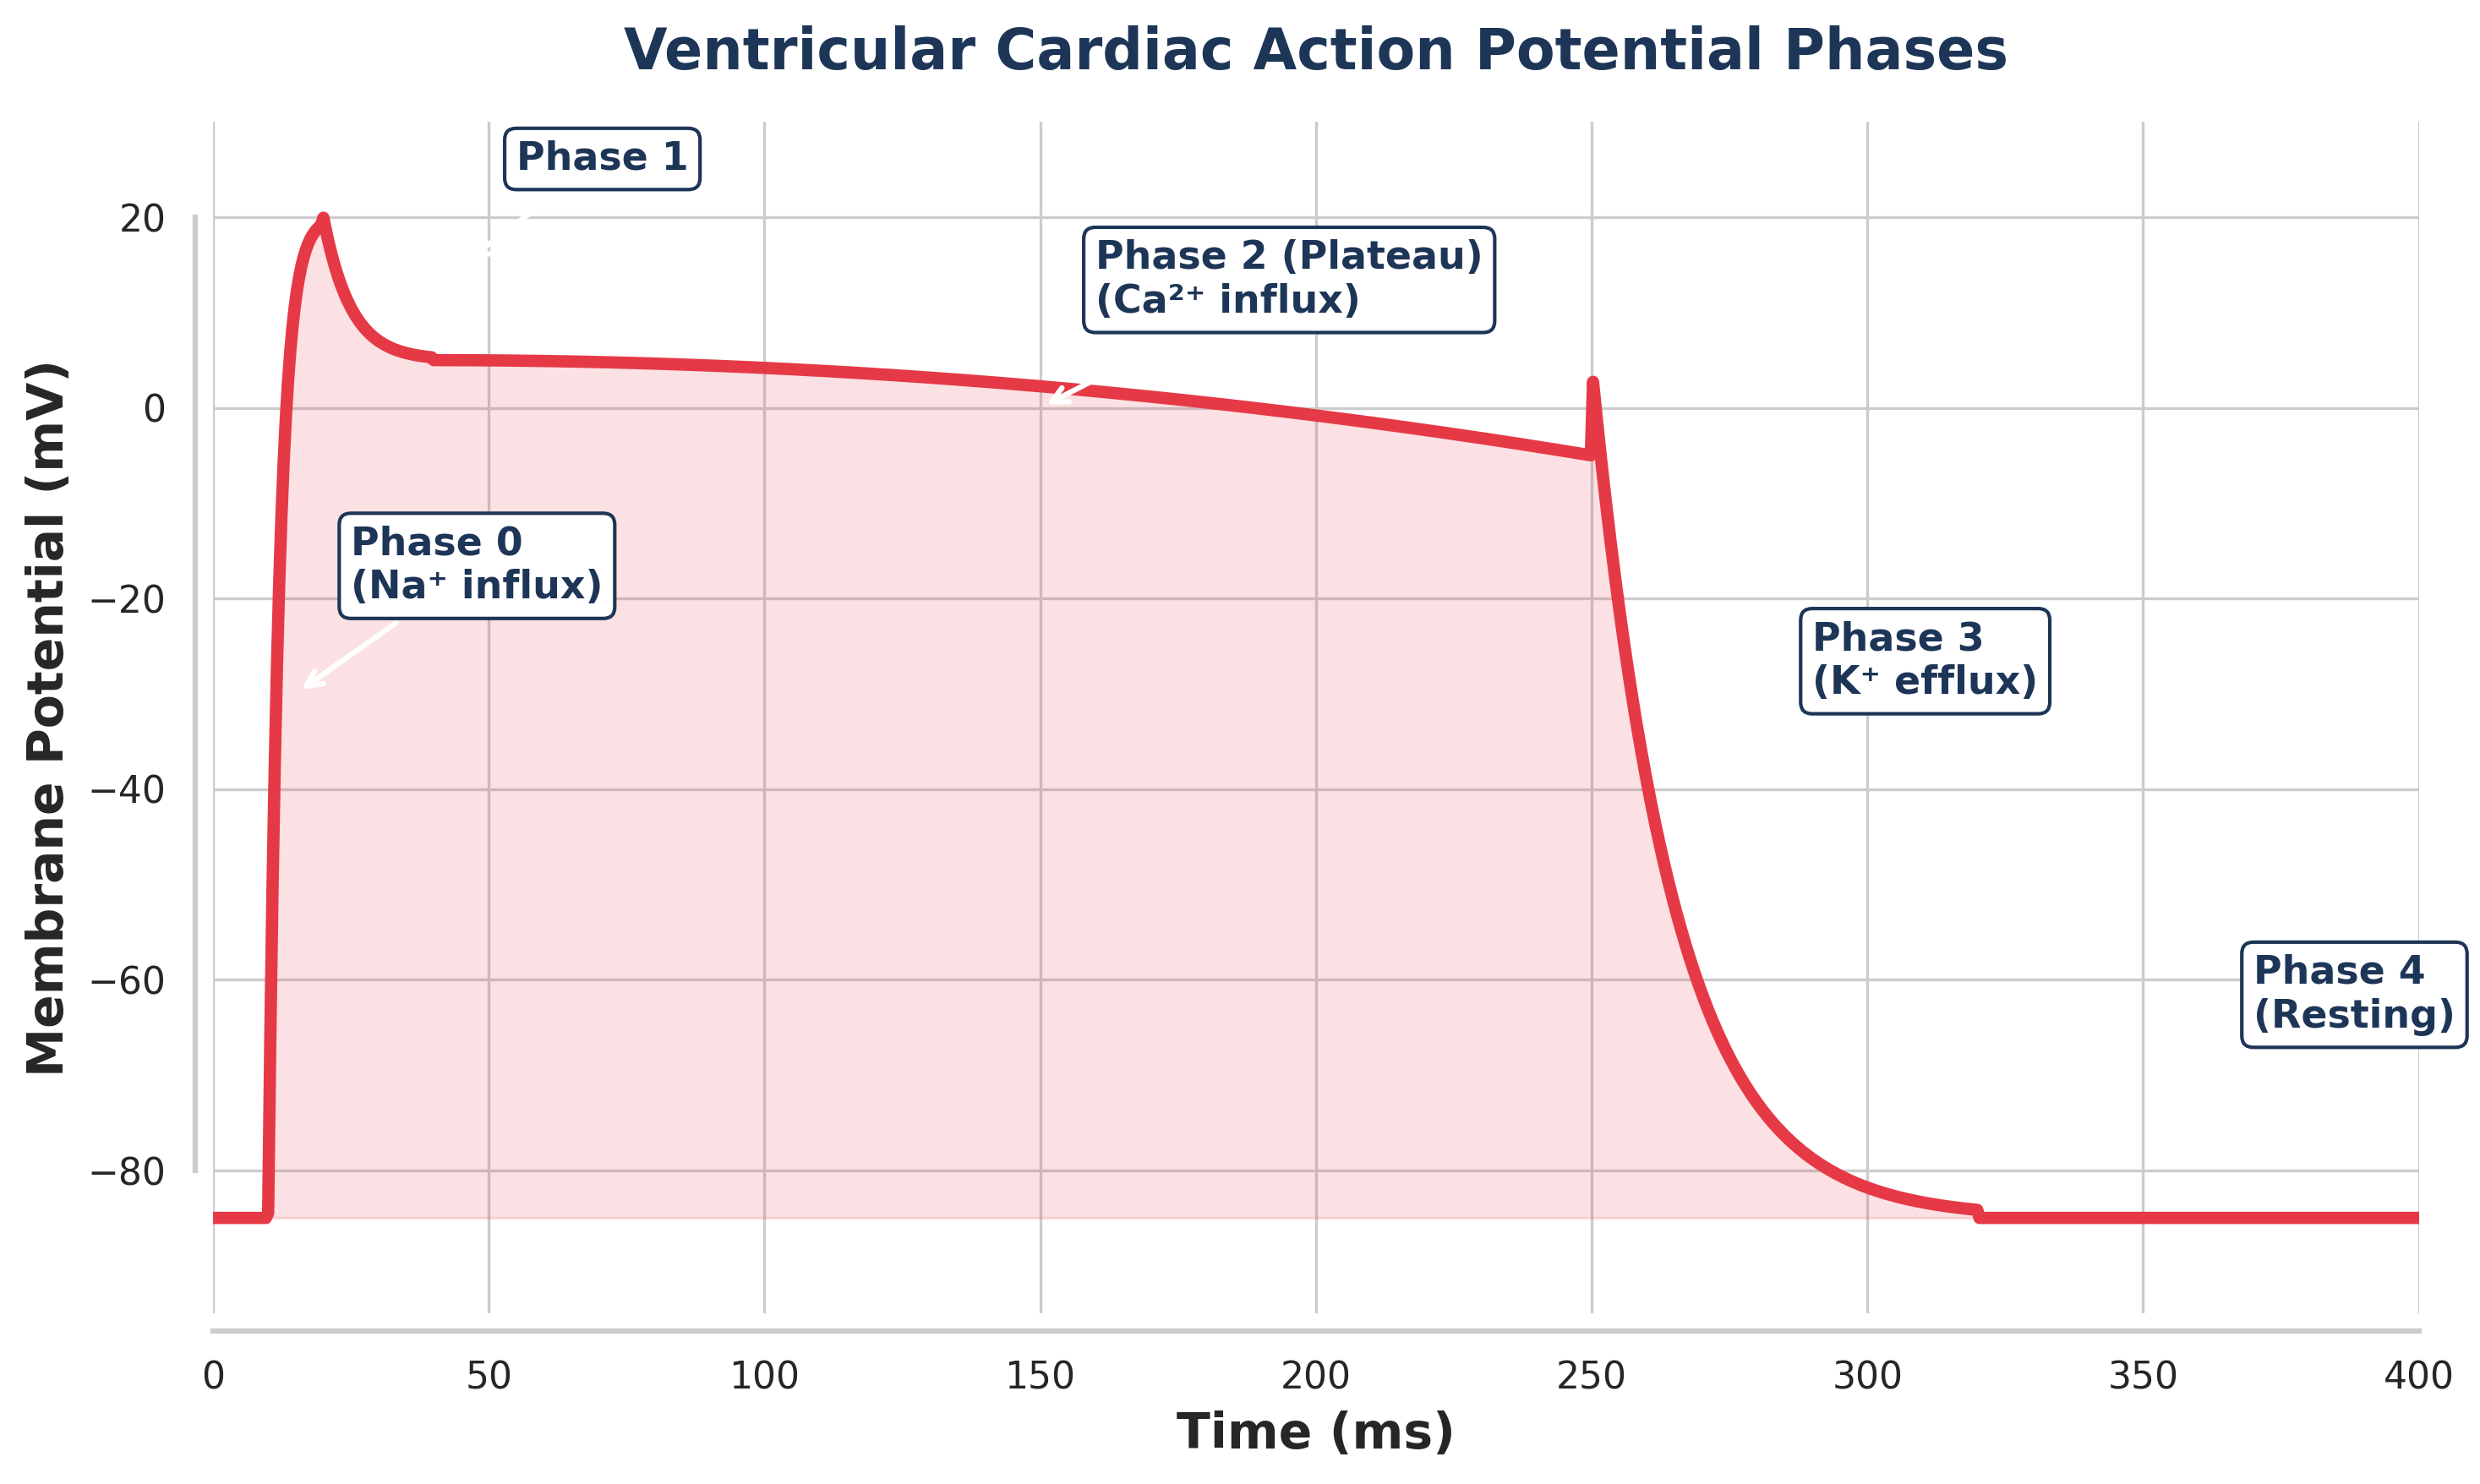

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set advanced aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.5

# Simulate a mock Action Potential curve
t = np.linspace(0, 400, 1000)
v_rest = -85
v_peak = 20

# Create a synthetic AP waveform using piecewise exponential functions
ap = np.zeros_like(t)
for i, time in enumerate(t):
    if time < 10:
        ap[i] = v_rest
    elif time < 20: # Phase 0
        ap[i] = v_rest + (v_peak - v_rest) * (1 - np.exp(-(time-10)/2))
    elif time < 40: # Phase 1
        ap[i] = v_peak - 15 * (1 - np.exp(-(time-20)/5))
    elif time < 250: # Phase 2 (Plateau)
        ap[i] = (v_peak - 15) - 10 * ((time-40)/210)**2
    elif time < 320: # Phase 3
        ap[i] = ap[249] - (ap[249] - v_rest) * (1 - np.exp(-(time-250)/15))
    else: # Phase 4
        ap[i] = v_rest

# Plotting
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(t, ap, color='#E63946', lw=3.5, label='Membrane Potential (mV)')

# Fill area under the curve for aesthetic depth
ax.fill_between(t, ap, v_rest, where=(ap > v_rest), color='#E63946', alpha=0.15)

# Annotations for Phases
annotations = [
    (15, -30, "Phase 0\n(Na⁺ influx)"),
    (45, 15, "Phase 1"),
    (150, 0, "Phase 2 (Plateau)\n(Ca²⁺ influx)"),
    (280, -40, "Phase 3\n(K⁺ efflux)"),
    (360, -75, "Phase 4\n(Resting)")
]

for x, y, text in annotations:
    ax.annotate(text, xy=(x, y), xytext=(x+10, y+10),
                arrowprops=dict(facecolor='black', arrowstyle="->", lw=1.5),
                fontsize=11, fontweight='bold', color='#1D3557',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1D3557", lw=1))

# Formatting
ax.set_title("Ventricular Cardiac Action Potential Phases", fontsize=16, fontweight='bold', pad=15, color='#1D3557')
ax.set_xlabel("Time (ms)", fontsize=14, fontweight='bold')
ax.set_ylabel("Membrane Potential (mV)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 400)
ax.set_ylim(-95, 30)
sns.despine(trim=True, offset=5)

plt.tight_layout()
plt.savefig("Figure_1_Action_Potential.png")
plt.show()

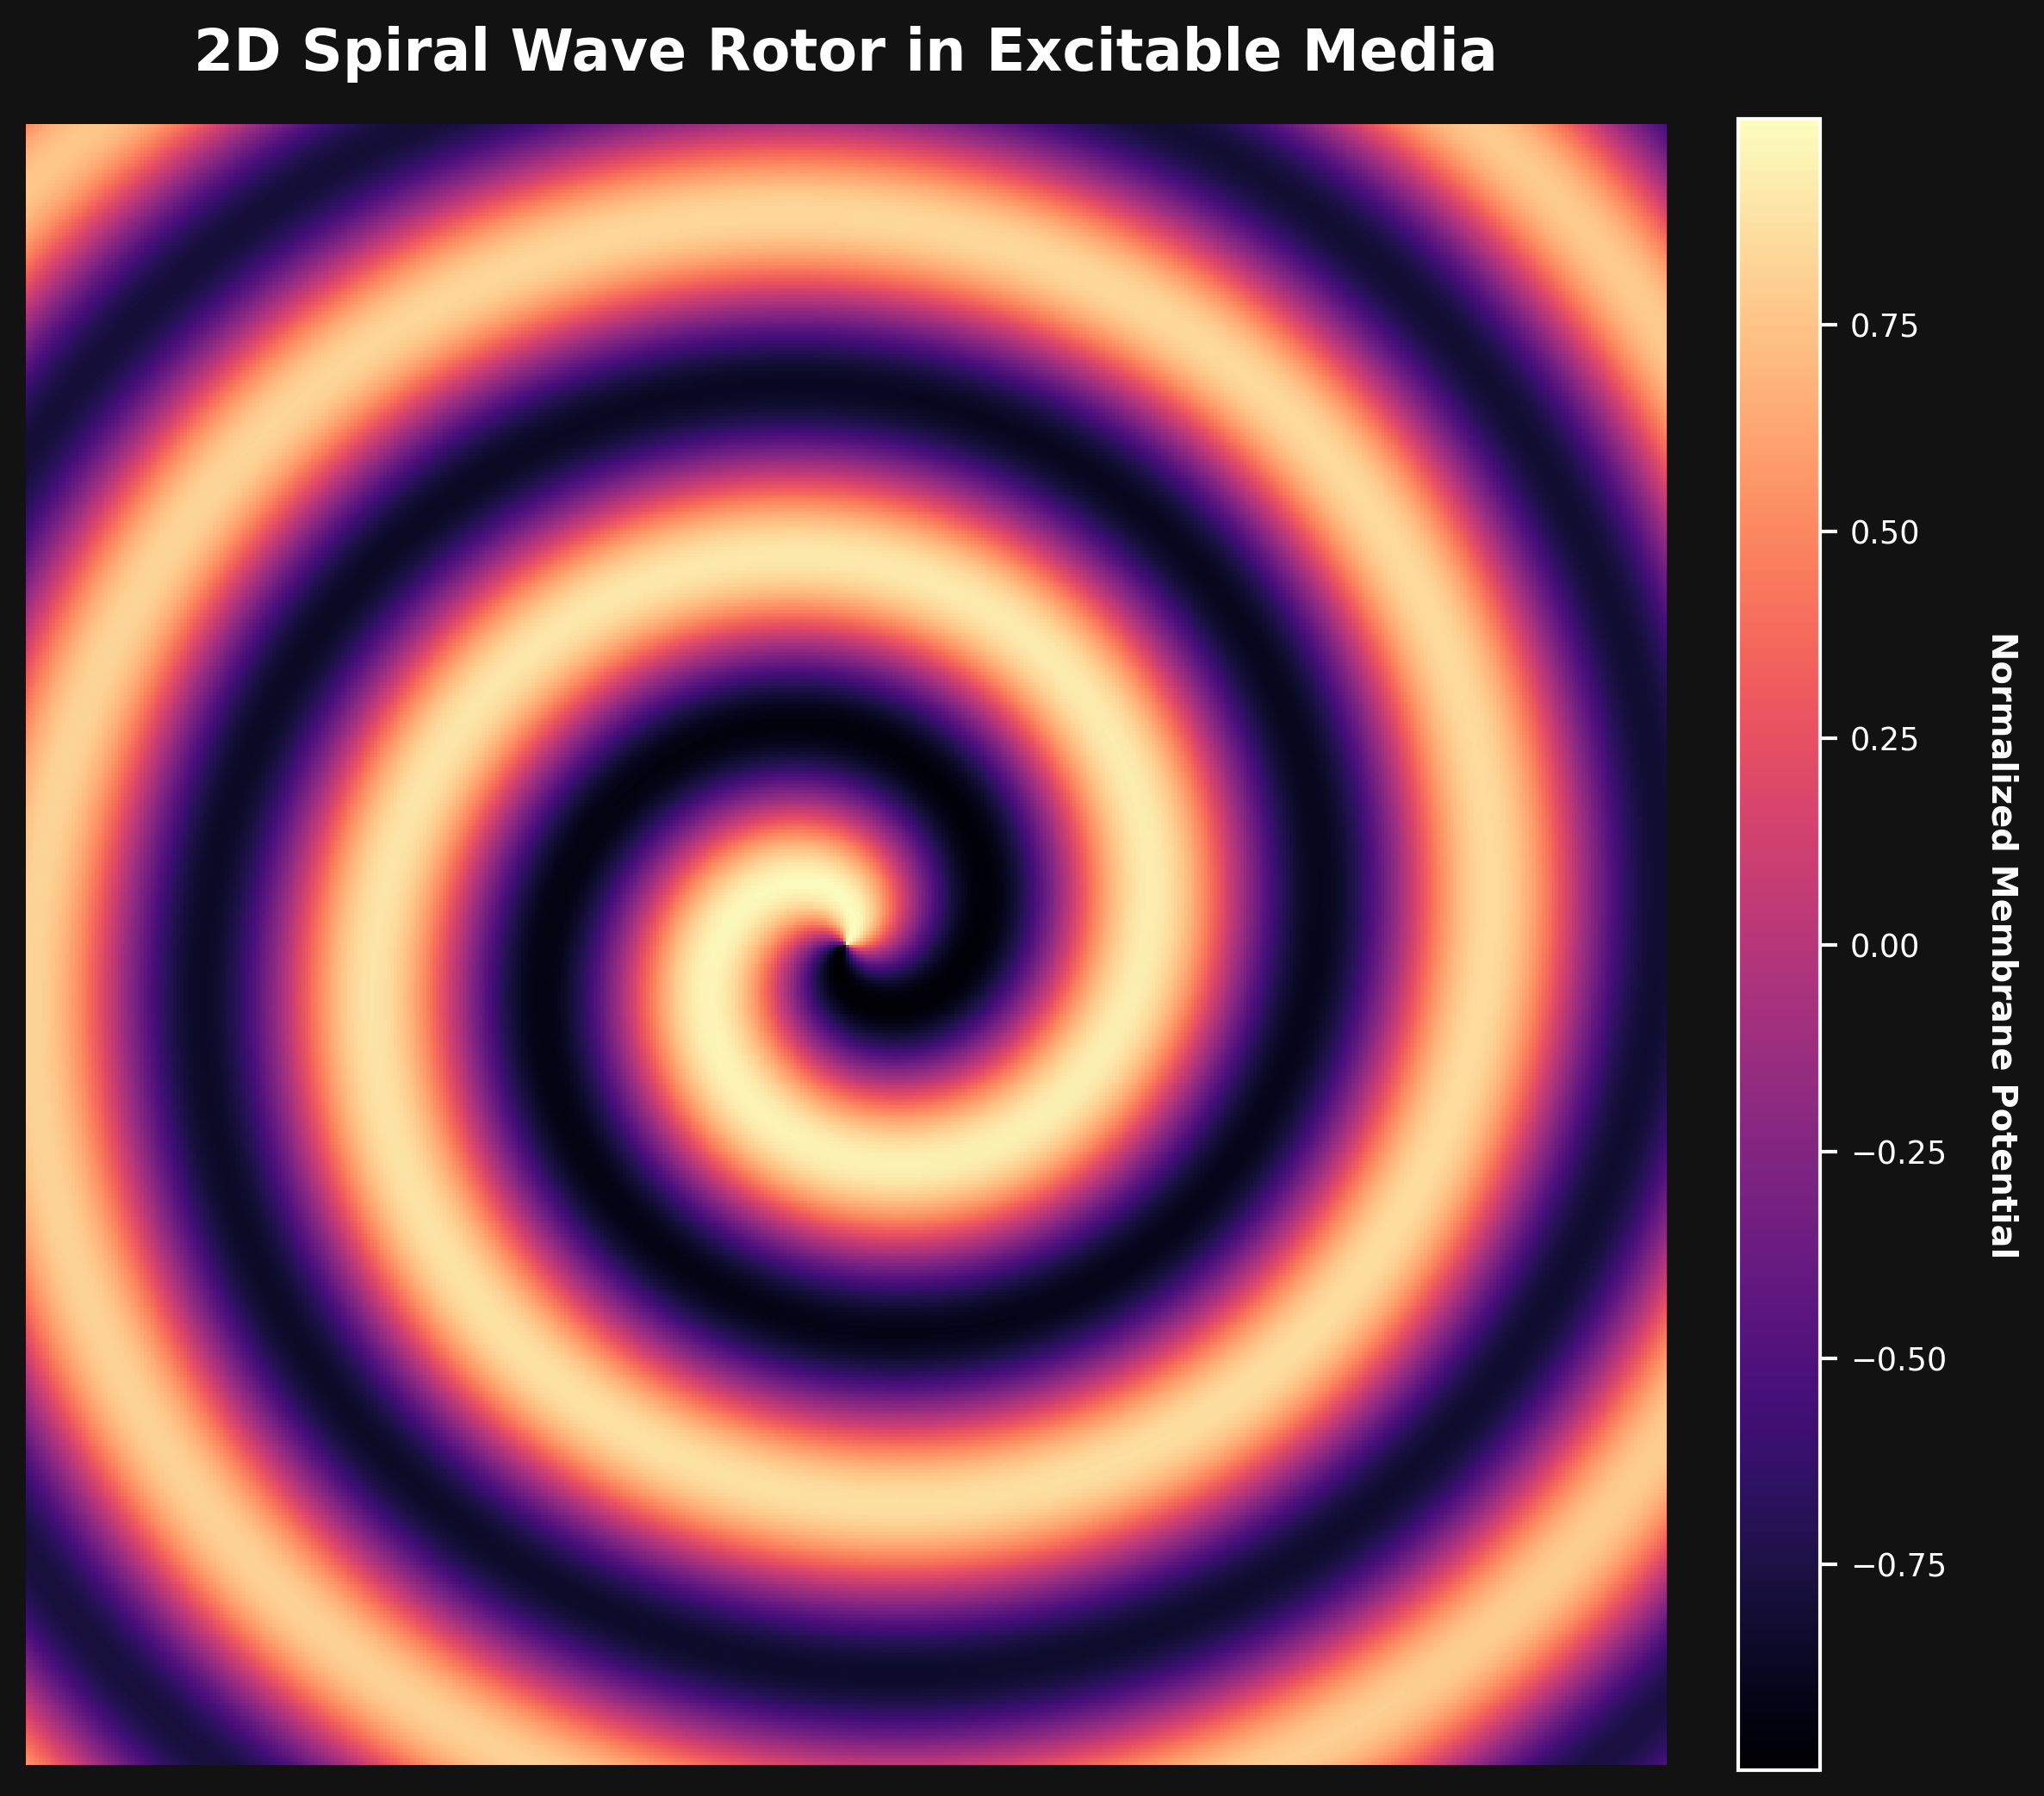

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
sns.set_theme(style="dark", context="paper")

# Generate a synthetic spiral wave using an Archimedean spiral formula mapped to a grid
x = np.linspace(-10, 10, 500)
y = np.linspace(-10, 10, 500)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

# Spiral wave equation: cos(k*R - omega*Theta)
k = 1.5      # Spatial frequency
omega = 1.0  # Angular frequency
spiral_wave = np.cos(k * R - omega * Theta + np.pi/4) * np.exp(-0.02 * R)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
# Use the highly aesthetic 'magma' colormap widely used in electrophysiology visualizations
im = ax.imshow(spiral_wave, extent=[-10, 10, -10, 10], cmap='magma', origin='lower')

# Remove axes for a clean, continuous medium look
ax.axis('off')
ax.set_title("2D Spiral Wave Rotor in Excitable Media",
             fontsize=16, fontweight='bold', color='white', pad=15)

# Add a colorbar to represent Voltage
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Membrane Potential', rotation=270, labelpad=20, color='white', fontweight='bold')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Set background to dark
fig.patch.set_facecolor('#121212')

plt.tight_layout()
plt.savefig("Figure_2_Spiral_Wave.png", facecolor='#121212')
plt.show()

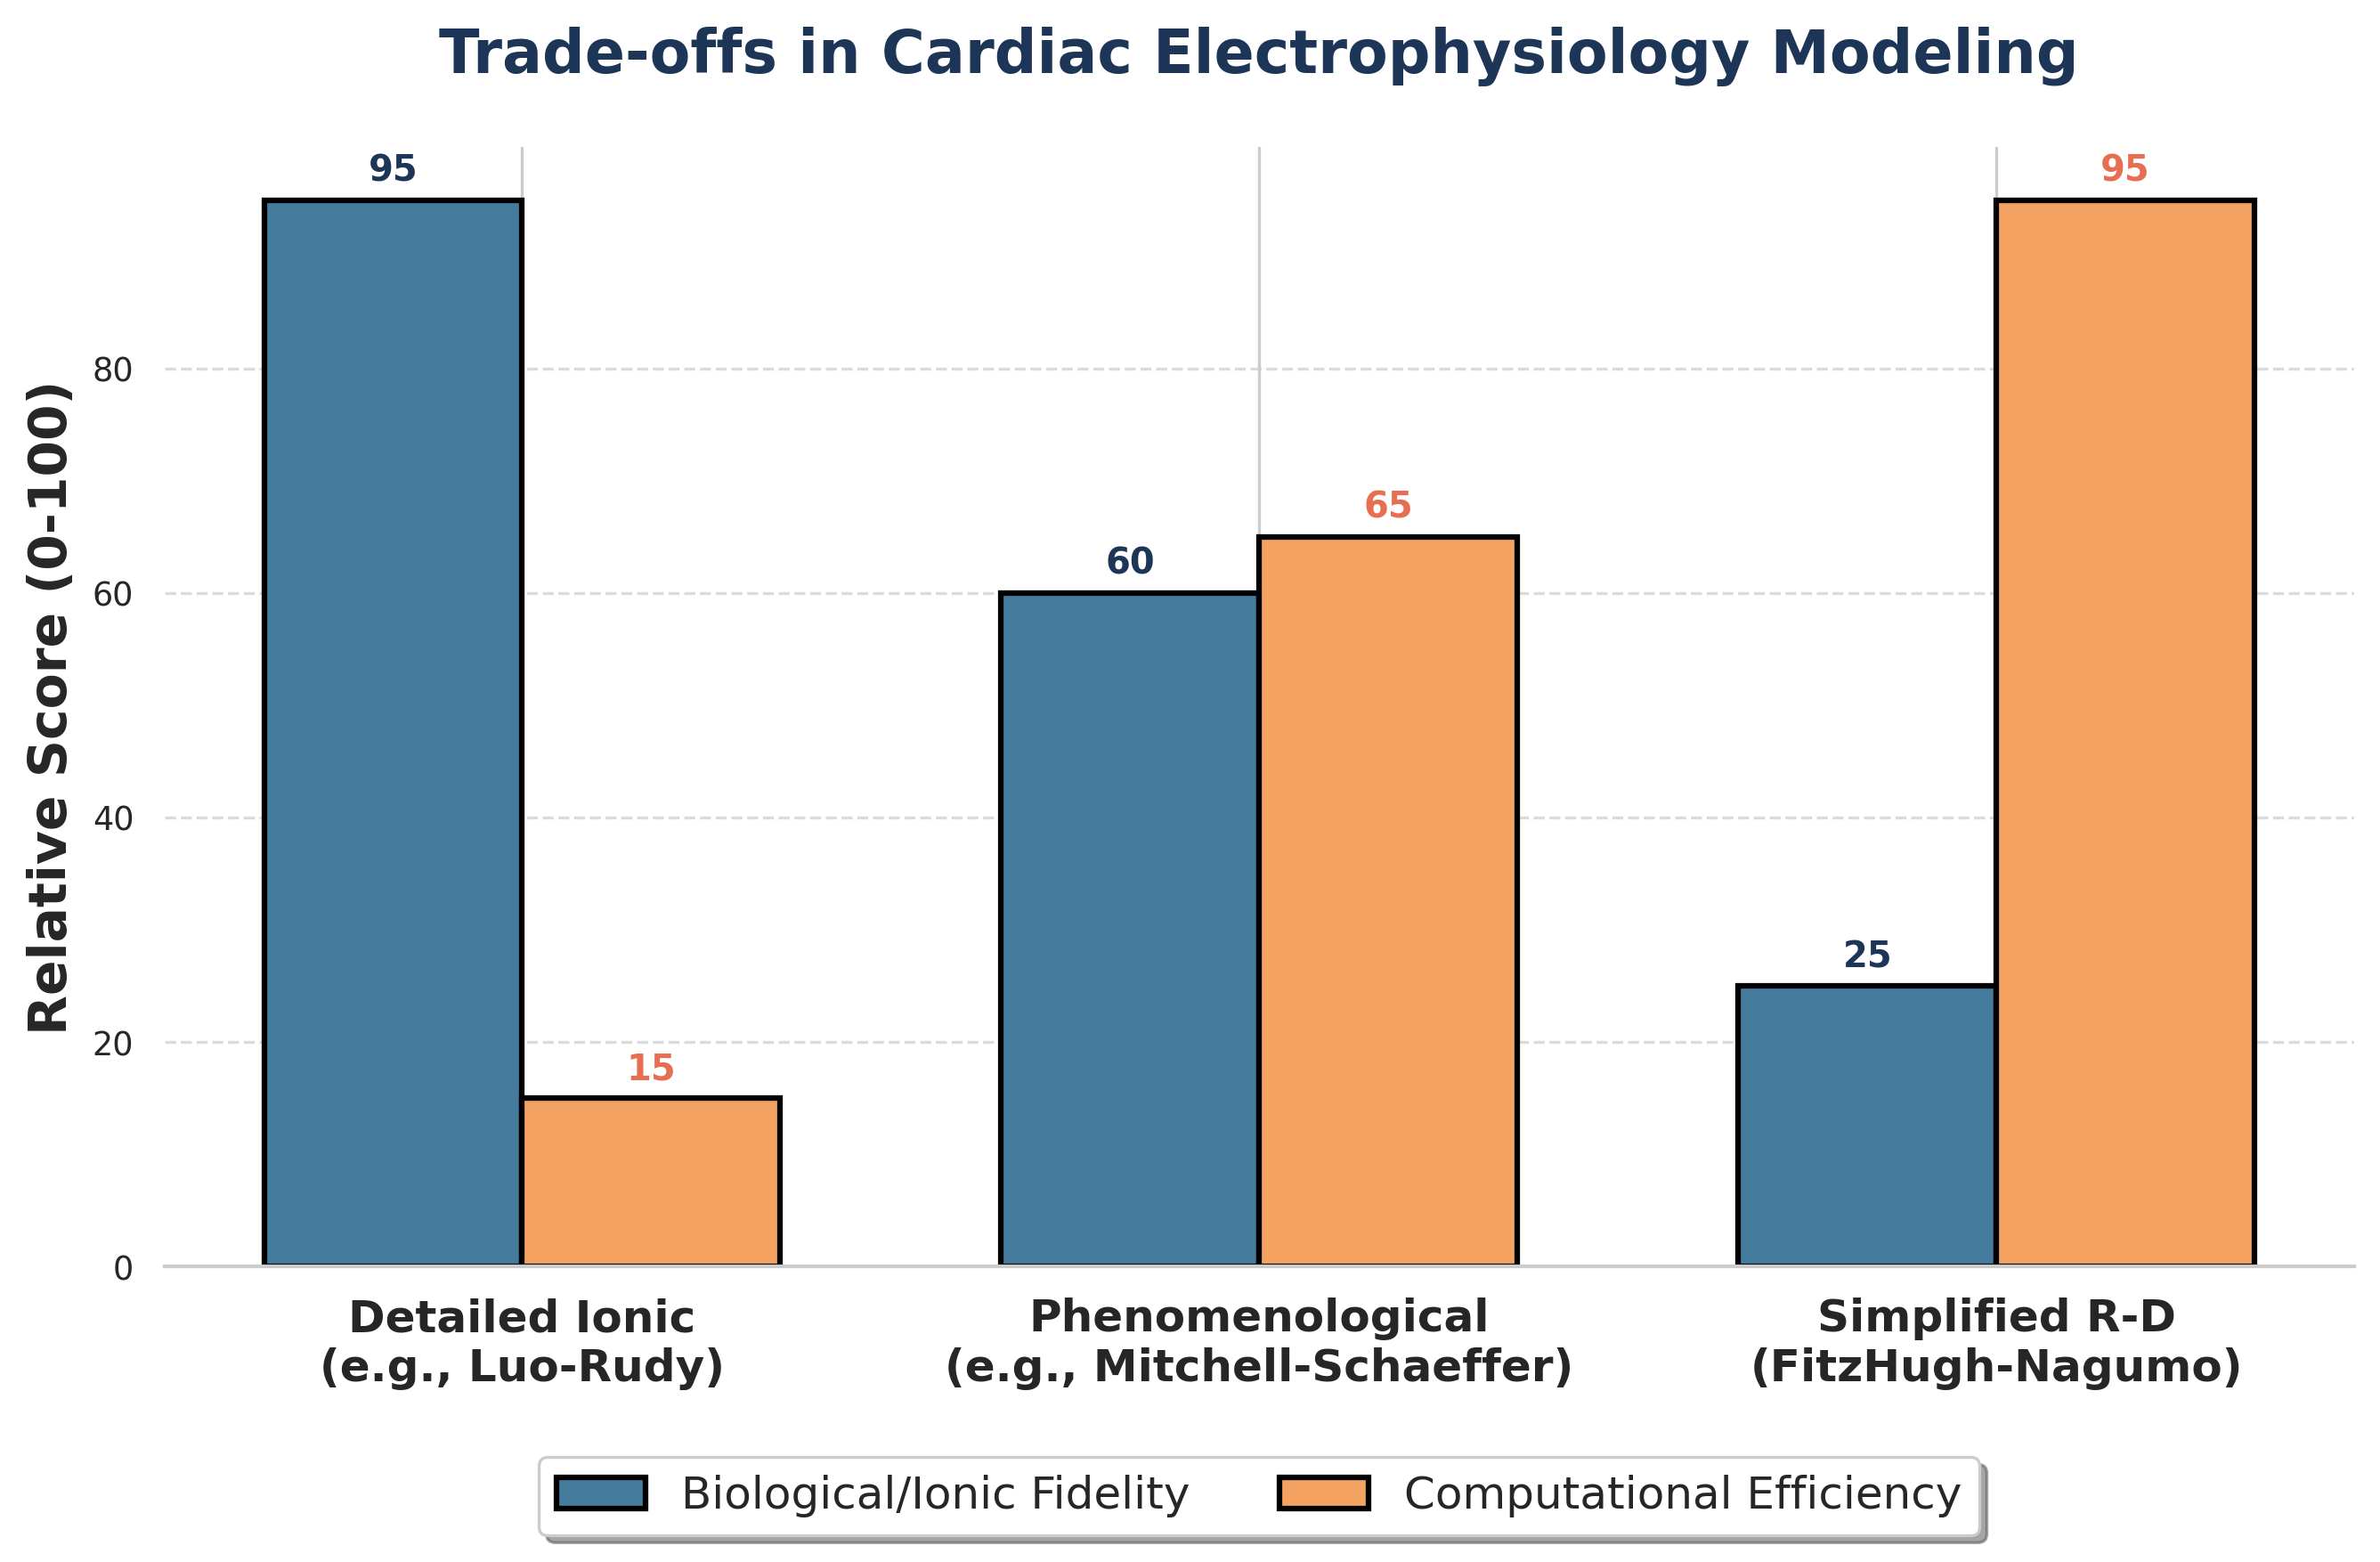

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

# Data for the graph
models = ['Detailed Ionic\n(e.g., Luo-Rudy)', 'Phenomenological\n(e.g., Mitchell-Schaeffer)', 'Simplified R-D\n(FitzHugh-Nagumo)']
biological_fidelity = [95, 60, 25]
computational_efficiency = [15, 65, 95]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
rects1 = ax.bar(x - width/2, biological_fidelity, width, label='Biological/Ionic Fidelity', color='#457B9D', edgecolor='black', lw=1.5)
rects2 = ax.bar(x + width/2, computational_efficiency, width, label='Computational Efficiency', color='#F4A261', edgecolor='black', lw=1.5)

# Add text labels on top of bars
ax.bar_label(rects1, padding=3, fontweight='bold', color='#1D3557')
ax.bar_label(rects2, padding=3, fontweight='bold', color='#E76F51')

ax.set_ylabel('Relative Score (0-100)', fontsize=14, fontweight='bold')
ax.set_title('Trade-offs in Cardiac Electrophysiology Modeling', fontsize=16, fontweight='bold', pad=20, color='#1D3557')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=2, fontsize=12)

sns.despine(left=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Figure_3_Model_Comparison.png", bbox_inches='tight')
plt.show()

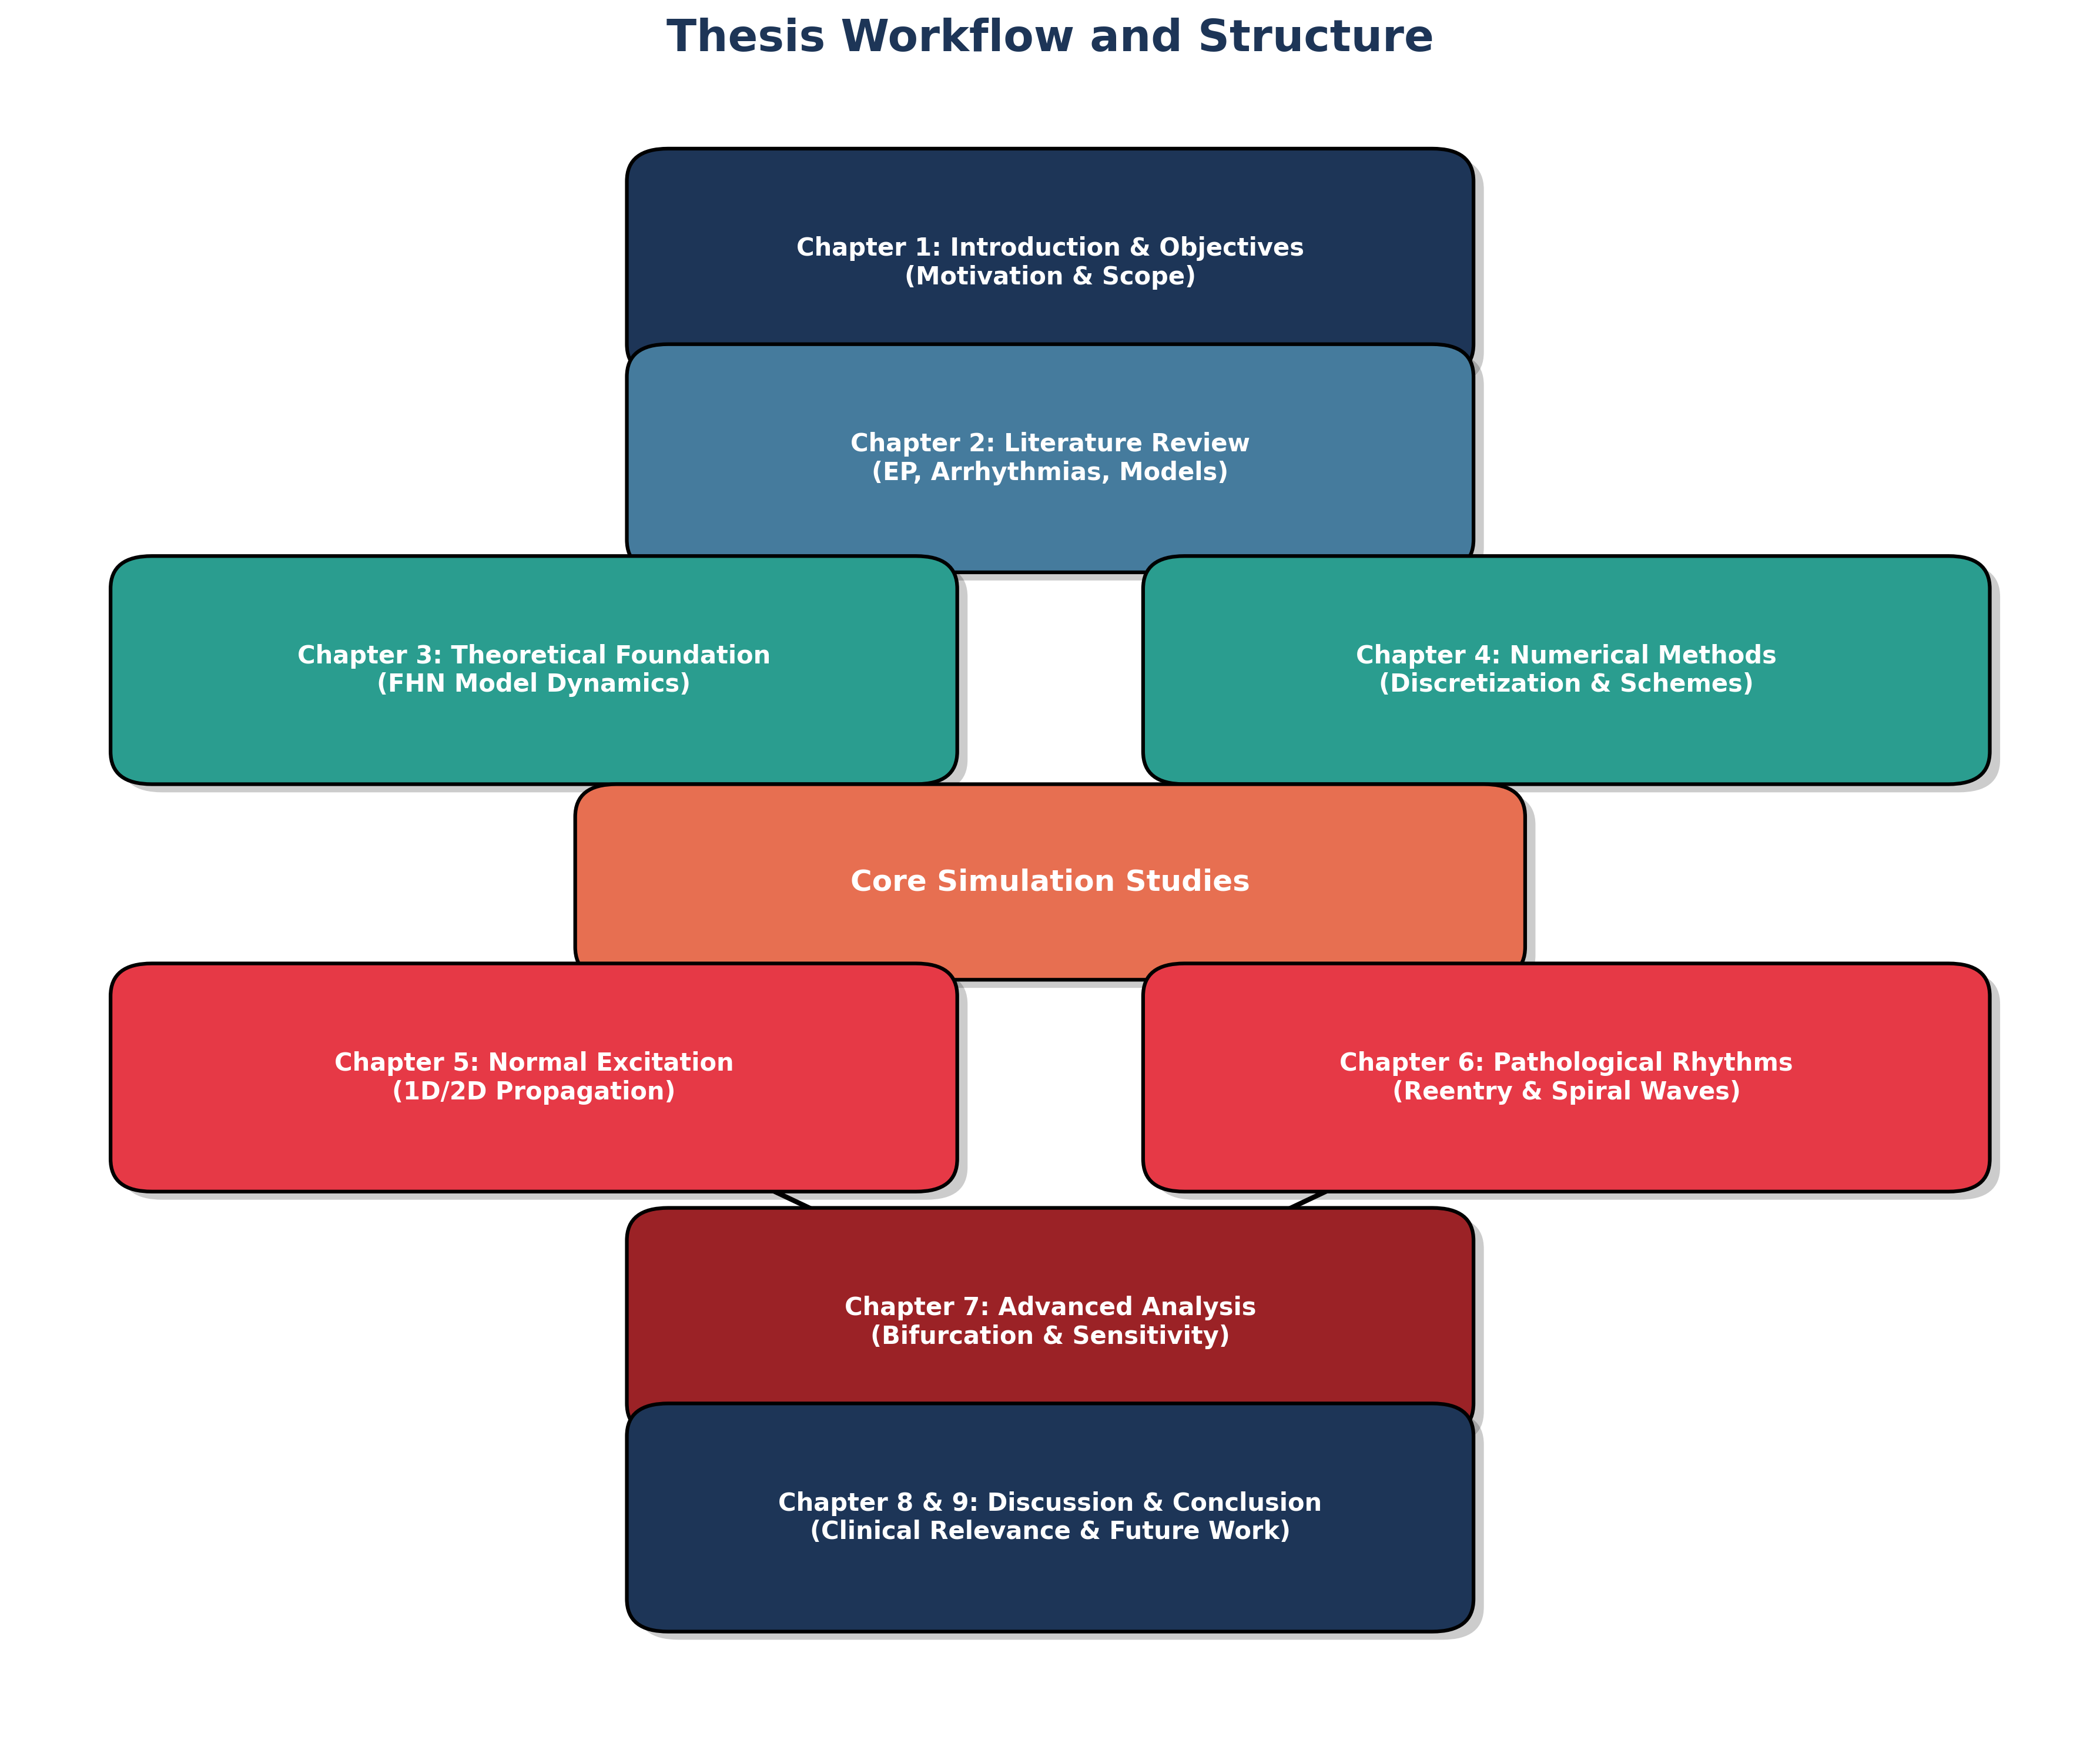

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white", context="paper")
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
ax.axis('off')

# Flowchart node definitions
nodes = {
    'Ch1': {'pos': (0.5, 0.9), 'text': 'Chapter 1: Introduction & Objectives\n(Motivation & Scope)', 'color': '#1D3557'},
    'Ch2': {'pos': (0.5, 0.78), 'text': 'Chapter 2: Literature Review\n(EP, Arrhythmias, Models)', 'color': '#457B9D'},
    'Ch3': {'pos': (0.25, 0.65), 'text': 'Chapter 3: Theoretical Foundation\n(FHN Model Dynamics)', 'color': '#2A9D8F'},
    'Ch4': {'pos': (0.75, 0.65), 'text': 'Chapter 4: Numerical Methods\n(Discretization & Schemes)', 'color': '#2A9D8F'},
    'Core': {'pos': (0.5, 0.52), 'text': 'Core Simulation Studies', 'color': '#E76F51', 'is_header': True},
    'Ch5': {'pos': (0.25, 0.4), 'text': 'Chapter 5: Normal Excitation\n(1D/2D Propagation)', 'color': '#E63946'},
    'Ch6': {'pos': (0.75, 0.4), 'text': 'Chapter 6: Pathological Rhythms\n(Reentry & Spiral Waves)', 'color': '#E63946'},
    'Ch7': {'pos': (0.5, 0.25), 'text': 'Chapter 7: Advanced Analysis\n(Bifurcation & Sensitivity)', 'color': '#9B2226'},
    'Ch8': {'pos': (0.5, 0.13), 'text': 'Chapter 8 & 9: Discussion & Conclusion\n(Clinical Relevance & Future Work)', 'color': '#1D3557'}
}

# Function to draw beautiful rounded boxes
def draw_box(ax, pos, text, color, is_header=False):
    width = 0.35 if not is_header else 0.4
    height = 0.08 if not is_header else 0.06
    x, y = pos
    box = mpatches.FancyBboxPatch((x - width/2, y - height/2), width, height,
                                  boxstyle="round,pad=0.03,rounding_size=0.02",
                                  edgecolor='black', facecolor=color, lw=1.5,
                                  zorder=3)
    # Add shadow
    shadow = mpatches.FancyBboxPatch((x - width/2 + 0.005, y - height/2 - 0.005), width, height,
                                  boxstyle="round,pad=0.03,rounding_size=0.02",
                                  edgecolor='none', facecolor='black', alpha=0.2,
                                  zorder=2)
    ax.add_patch(shadow)
    ax.add_patch(box)

    font_color = 'white'
    weight = 'bold' if is_header else 'normal'
    size = 12 if is_header else 10
    ax.text(x, y, text, ha='center', va='center', color=font_color,
            fontsize=size, fontweight='bold', zorder=4)

# Draw arrows
def draw_arrow(ax, pos1, pos2):
    ax.annotate("", xy=pos2, xycoords='data', xytext=pos1, textcoords='data',
                arrowprops=dict(arrowstyle="->", color="black", lw=2,
                                shrinkA=15, shrinkB=15, patchA=None, patchB=None,
                                connectionstyle="arc3,rad=0.0"), zorder=1)

# Render boxes
for key, node in nodes.items():
    draw_box(ax, node['pos'], node['text'], node['color'], node.get('is_header', False))

# Draw connections
draw_arrow(ax, nodes['Ch1']['pos'], nodes['Ch2']['pos'])
draw_arrow(ax, nodes['Ch2']['pos'], nodes['Ch3']['pos'])
draw_arrow(ax, nodes['Ch2']['pos'], nodes['Ch4']['pos'])
draw_arrow(ax, nodes['Ch3']['pos'], nodes['Core']['pos'])
draw_arrow(ax, nodes['Ch4']['pos'], nodes['Core']['pos'])
draw_arrow(ax, nodes['Core']['pos'], nodes['Ch5']['pos'])
draw_arrow(ax, nodes['Core']['pos'], nodes['Ch6']['pos'])
draw_arrow(ax, nodes['Ch5']['pos'], nodes['Ch7']['pos'])
draw_arrow(ax, nodes['Ch6']['pos'], nodes['Ch7']['pos'])
draw_arrow(ax, nodes['Ch7']['pos'], nodes['Ch8']['pos'])

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("Thesis Workflow and Structure", fontsize=18, fontweight='bold', color='#1D3557', pad=20)
plt.tight_layout()
plt.savefig("Figure_4_Thesis_Flowchart.png", bbox_inches='tight')
plt.show()

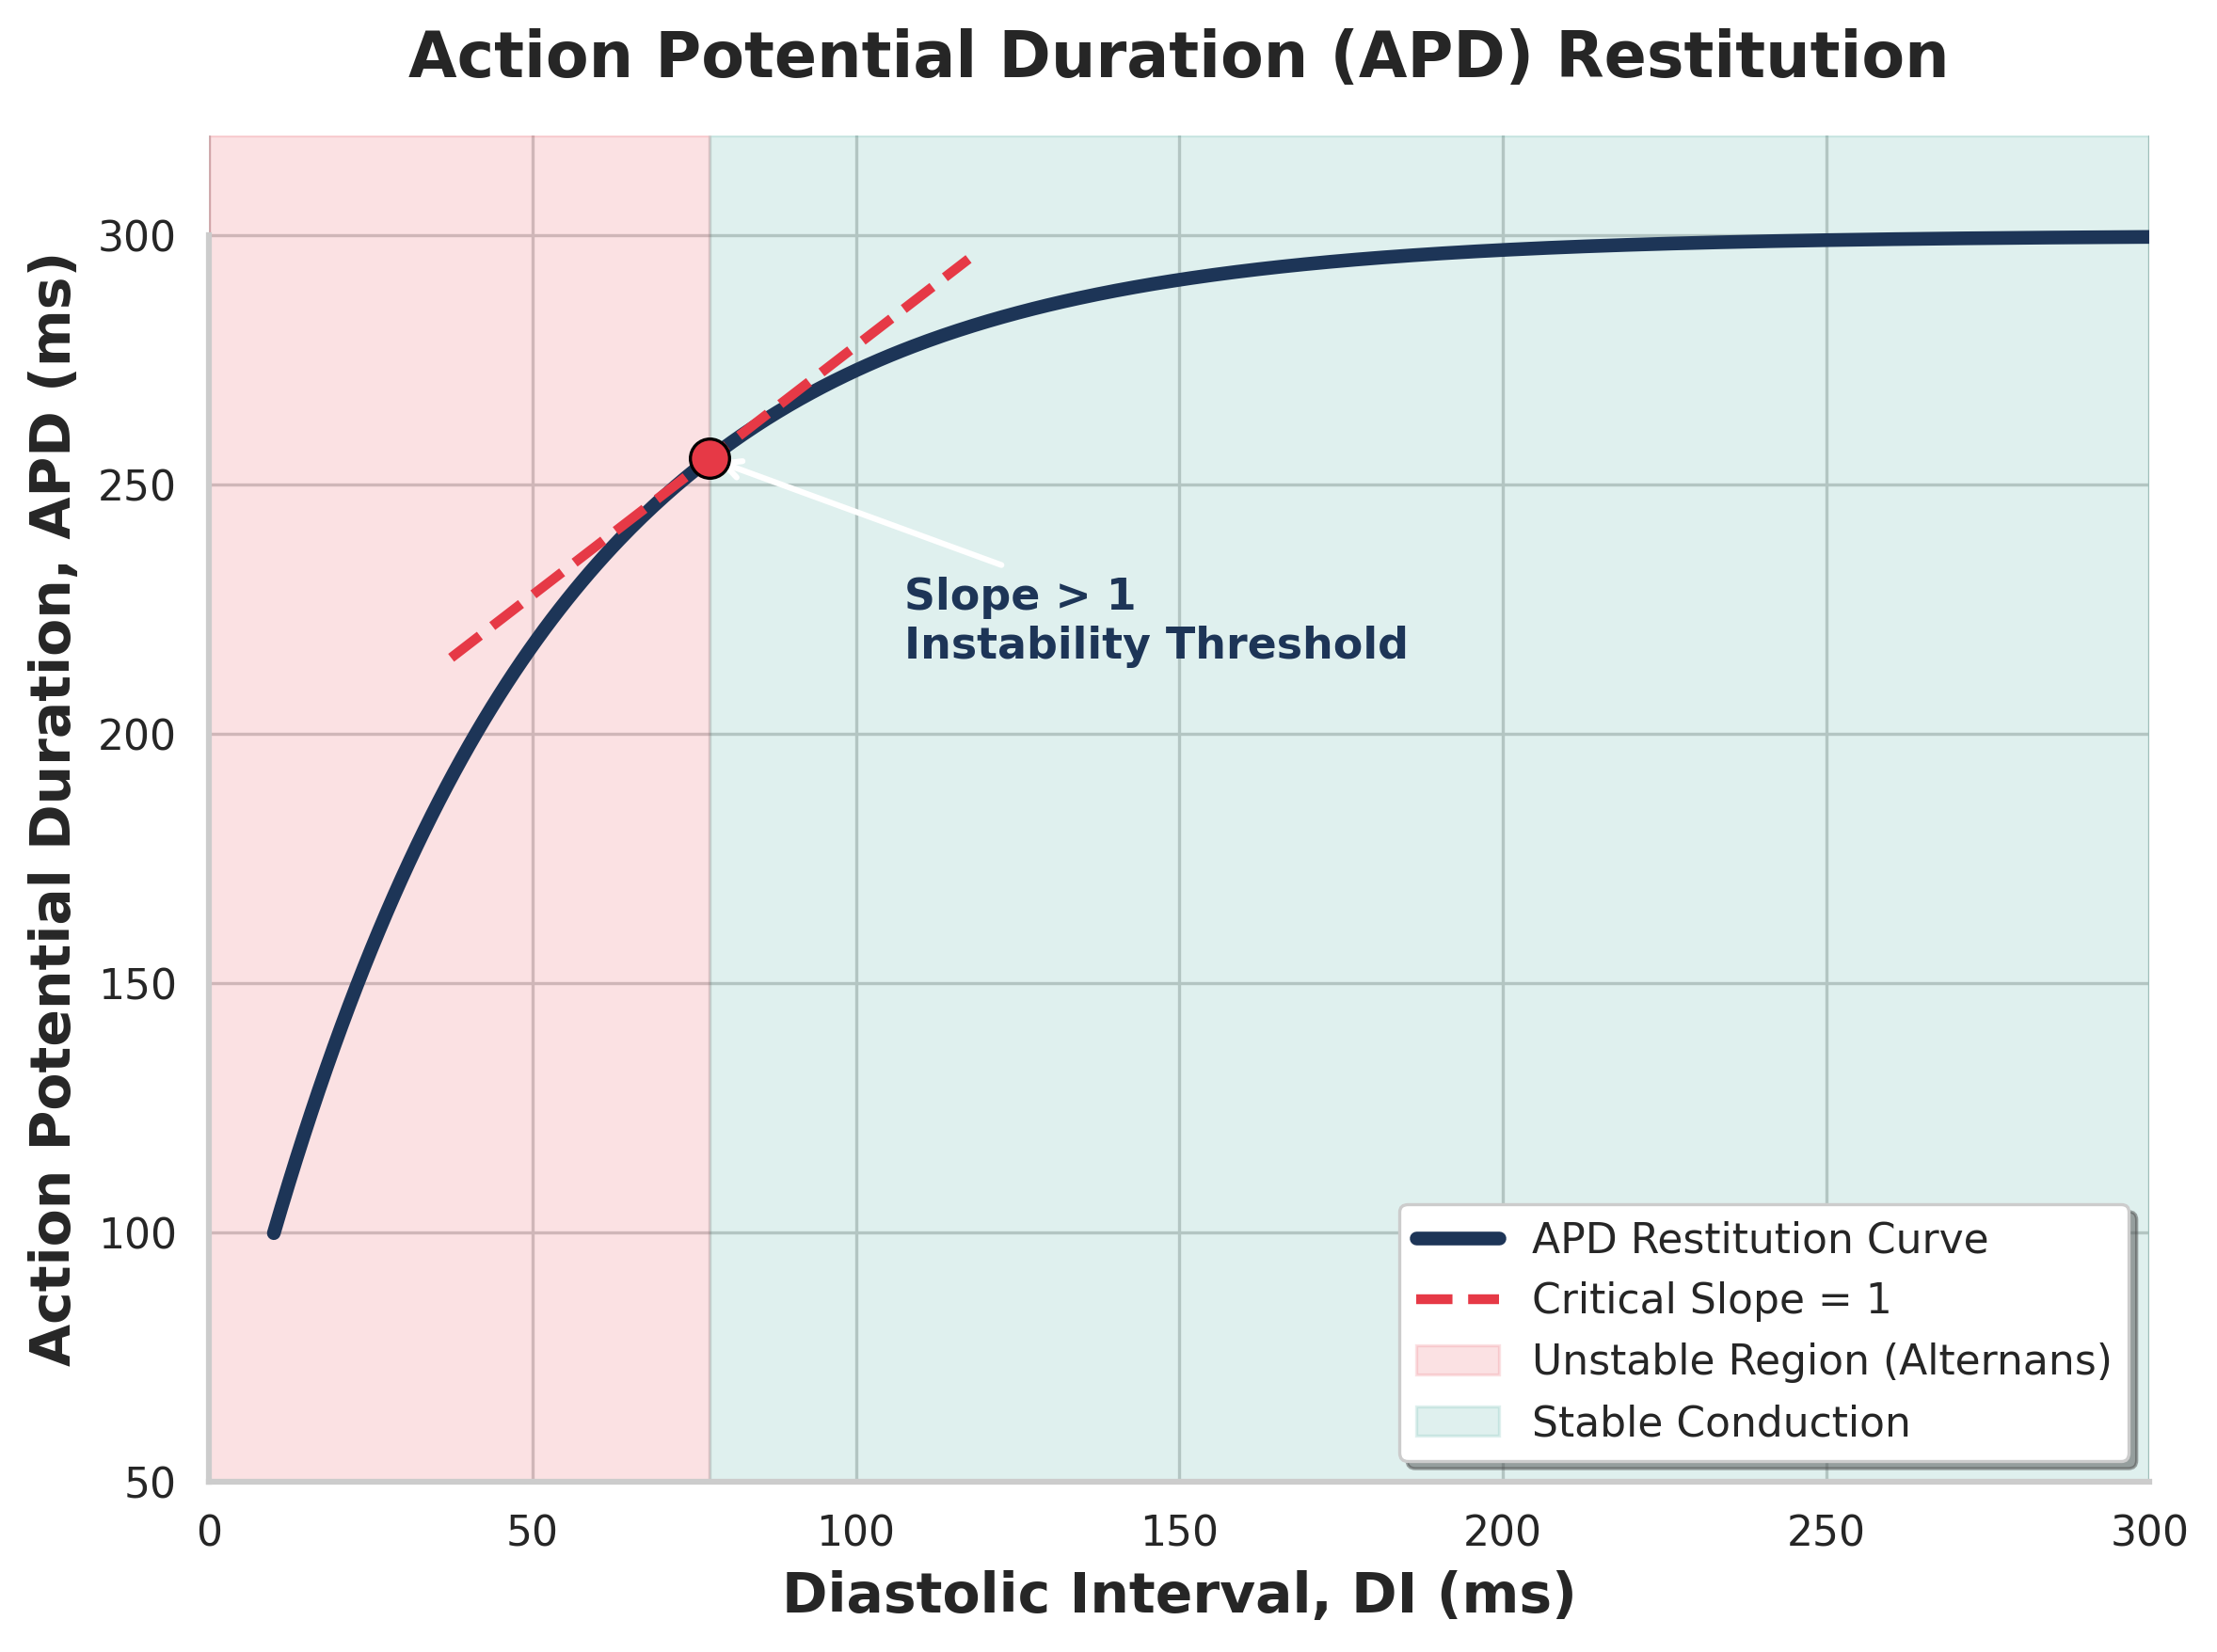

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Advanced aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.5

# Generate DI and APD data (exponential restitution model)
di = np.linspace(10, 300, 500)
apd_max = 300
A = 250
tau = 45
apd = apd_max - A * np.exp(-di / tau)

# Calculate slope derivative: d(APD)/d(DI) = (A/tau) * exp(-DI/tau)
slope = (A / tau) * np.exp(-di / tau)
# Find DI where slope is approximately 1
critical_idx = np.argmin(np.abs(slope - 1.0))
di_crit = di[critical_idx]
apd_crit = apd[critical_idx]

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Plot restitution curve
ax.plot(di, apd, color='#1D3557', lw=3.5, label='APD Restitution Curve')

# Plot slope = 1 tangent line
x_tan = np.linspace(di_crit - 40, di_crit + 40, 10)
y_tan = 1.0 * (x_tan - di_crit) + apd_crit
ax.plot(x_tan, y_tan, color='#E63946', lw=2.5, linestyle='--',
        label=r'Critical Slope = 1')

# Highlight the unstable and stable regions
ax.axvspan(0, di_crit, color='#E63946', alpha=0.15, label='Unstable Region (Alternans)')
ax.axvspan(di_crit, 300, color='#2A9D8F', alpha=0.15, label='Stable Conduction')

# Scatter point for critical threshold
ax.scatter(di_crit, apd_crit, color='#E63946', s=100, zorder=5, edgecolor='black')
ax.annotate('Slope > 1\nInstability Threshold',
            xy=(di_crit, apd_crit), xytext=(di_crit + 30, apd_crit - 40),
            arrowprops=dict(facecolor='black', arrowstyle="->", lw=1.5),
            fontsize=11, fontweight='bold', color='#1D3557')

# Formatting
ax.set_title("Action Potential Duration (APD) Restitution", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Diastolic Interval, DI (ms)", fontsize=14, fontweight='bold')
ax.set_ylabel("Action Potential Duration, APD (ms)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 300)
ax.set_ylim(50, 320)
ax.legend(loc='lower right', frameon=True, shadow=True)

sns.despine(trim=True)
plt.tight_layout()
plt.savefig("Figure_2_1_Restitution.png")
plt.show()

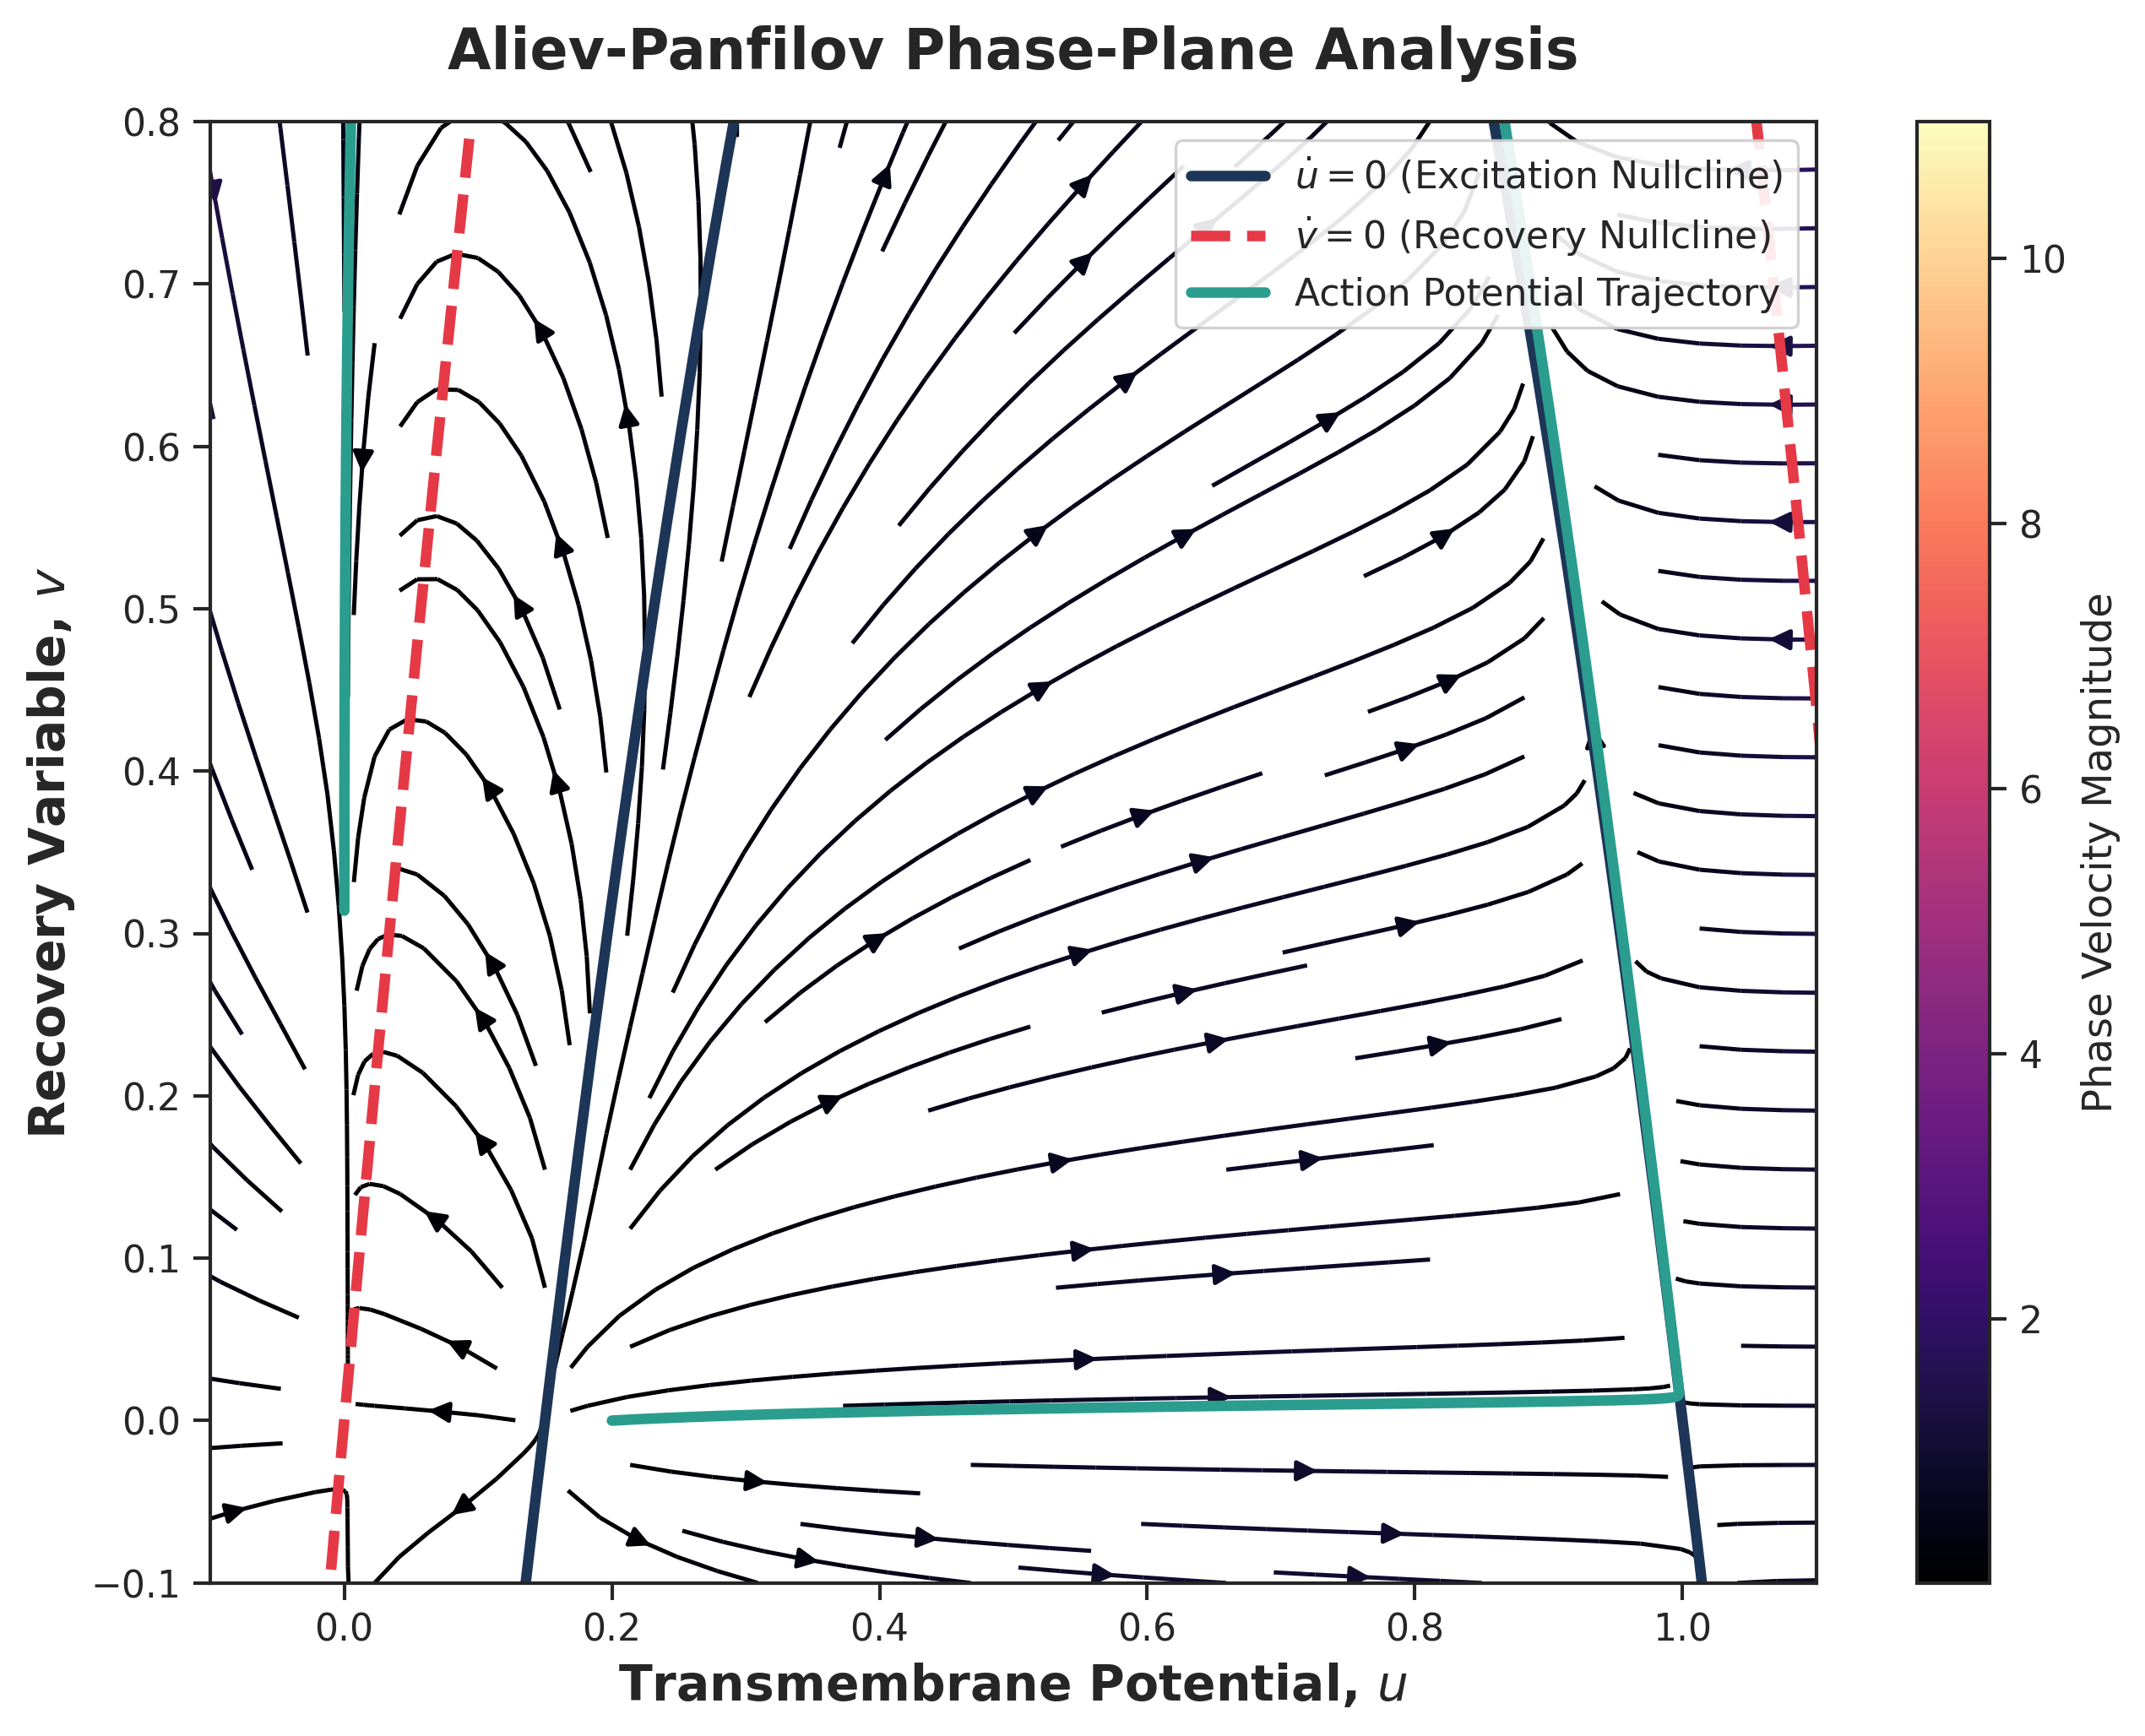

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Aliev-Panfilov Parameters
k = 8.0
a = 0.15
eps = 0.002
mu1 = 0.2
mu2 = 0.3

# Grid for vector field
u = np.linspace(-0.2, 1.2, 30)
v = np.linspace(-0.1, 1.5, 30)
U, V = np.meshgrid(u, v)

# Differential equations
dUdt = k * U * (1 - U) * (U - a) - U * V
dVdt = (eps + (mu1 * V) / (U + mu2)) * (-V - k * U * (U - a - 1))

fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# Streamplot for aesthetic vector field
strm = ax.streamplot(U, V, dUdt, dVdt, color=np.sqrt(dUdt**2 + dVdt**2),
                     cmap='magma', linewidth=1.2, density=1.5, arrowsize=1.2)
fig.colorbar(strm.lines, ax=ax, label='Phase Velocity Magnitude')

# Nullclines
u_null_x = np.linspace(0.01, 1.1, 100)
u_null_y = k * (1 - u_null_x) * (u_null_x - a)
v_null_x = np.linspace(-0.2, 1.2, 100)
v_null_y = -k * v_null_x * (v_null_x - a - 1)

ax.plot(u_null_x, u_null_y, '#1D3557', lw=3, label=r'$\dot{u} = 0$ (Excitation Nullcline)')
ax.plot(v_null_x, v_null_y, '#E63946', lw=3, linestyle='--', label=r'$\dot{v} = 0$ (Recovery Nullcline)')

# Single trajectory simulation (Euler method)
u_traj, v_traj = [0.2], [0.0] # Initial condition slightly above threshold a
dt = 0.01
for _ in range(3000):
    ui, vi = u_traj[-1], v_traj[-1]
    du = k * ui * (1 - ui) * (ui - a) - ui * vi
    dv = (eps + (mu1 * vi) / (ui + mu2)) * (-vi - k * ui * (ui - a - 1))
    u_traj.append(ui + du * dt)
    v_traj.append(vi + dv * dt)

ax.plot(u_traj, v_traj, color='#2A9D8F', lw=3, label='Action Potential Trajectory')

# Formatting
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 0.8)
ax.set_xlabel(r'Transmembrane Potential, $u$', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Recovery Variable, $v$', fontsize=14, fontweight='bold')
ax.set_title("Aliev-Panfilov Phase-Plane Analysis", fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig("Figure_2_2_PhasePlane.png")
plt.show()

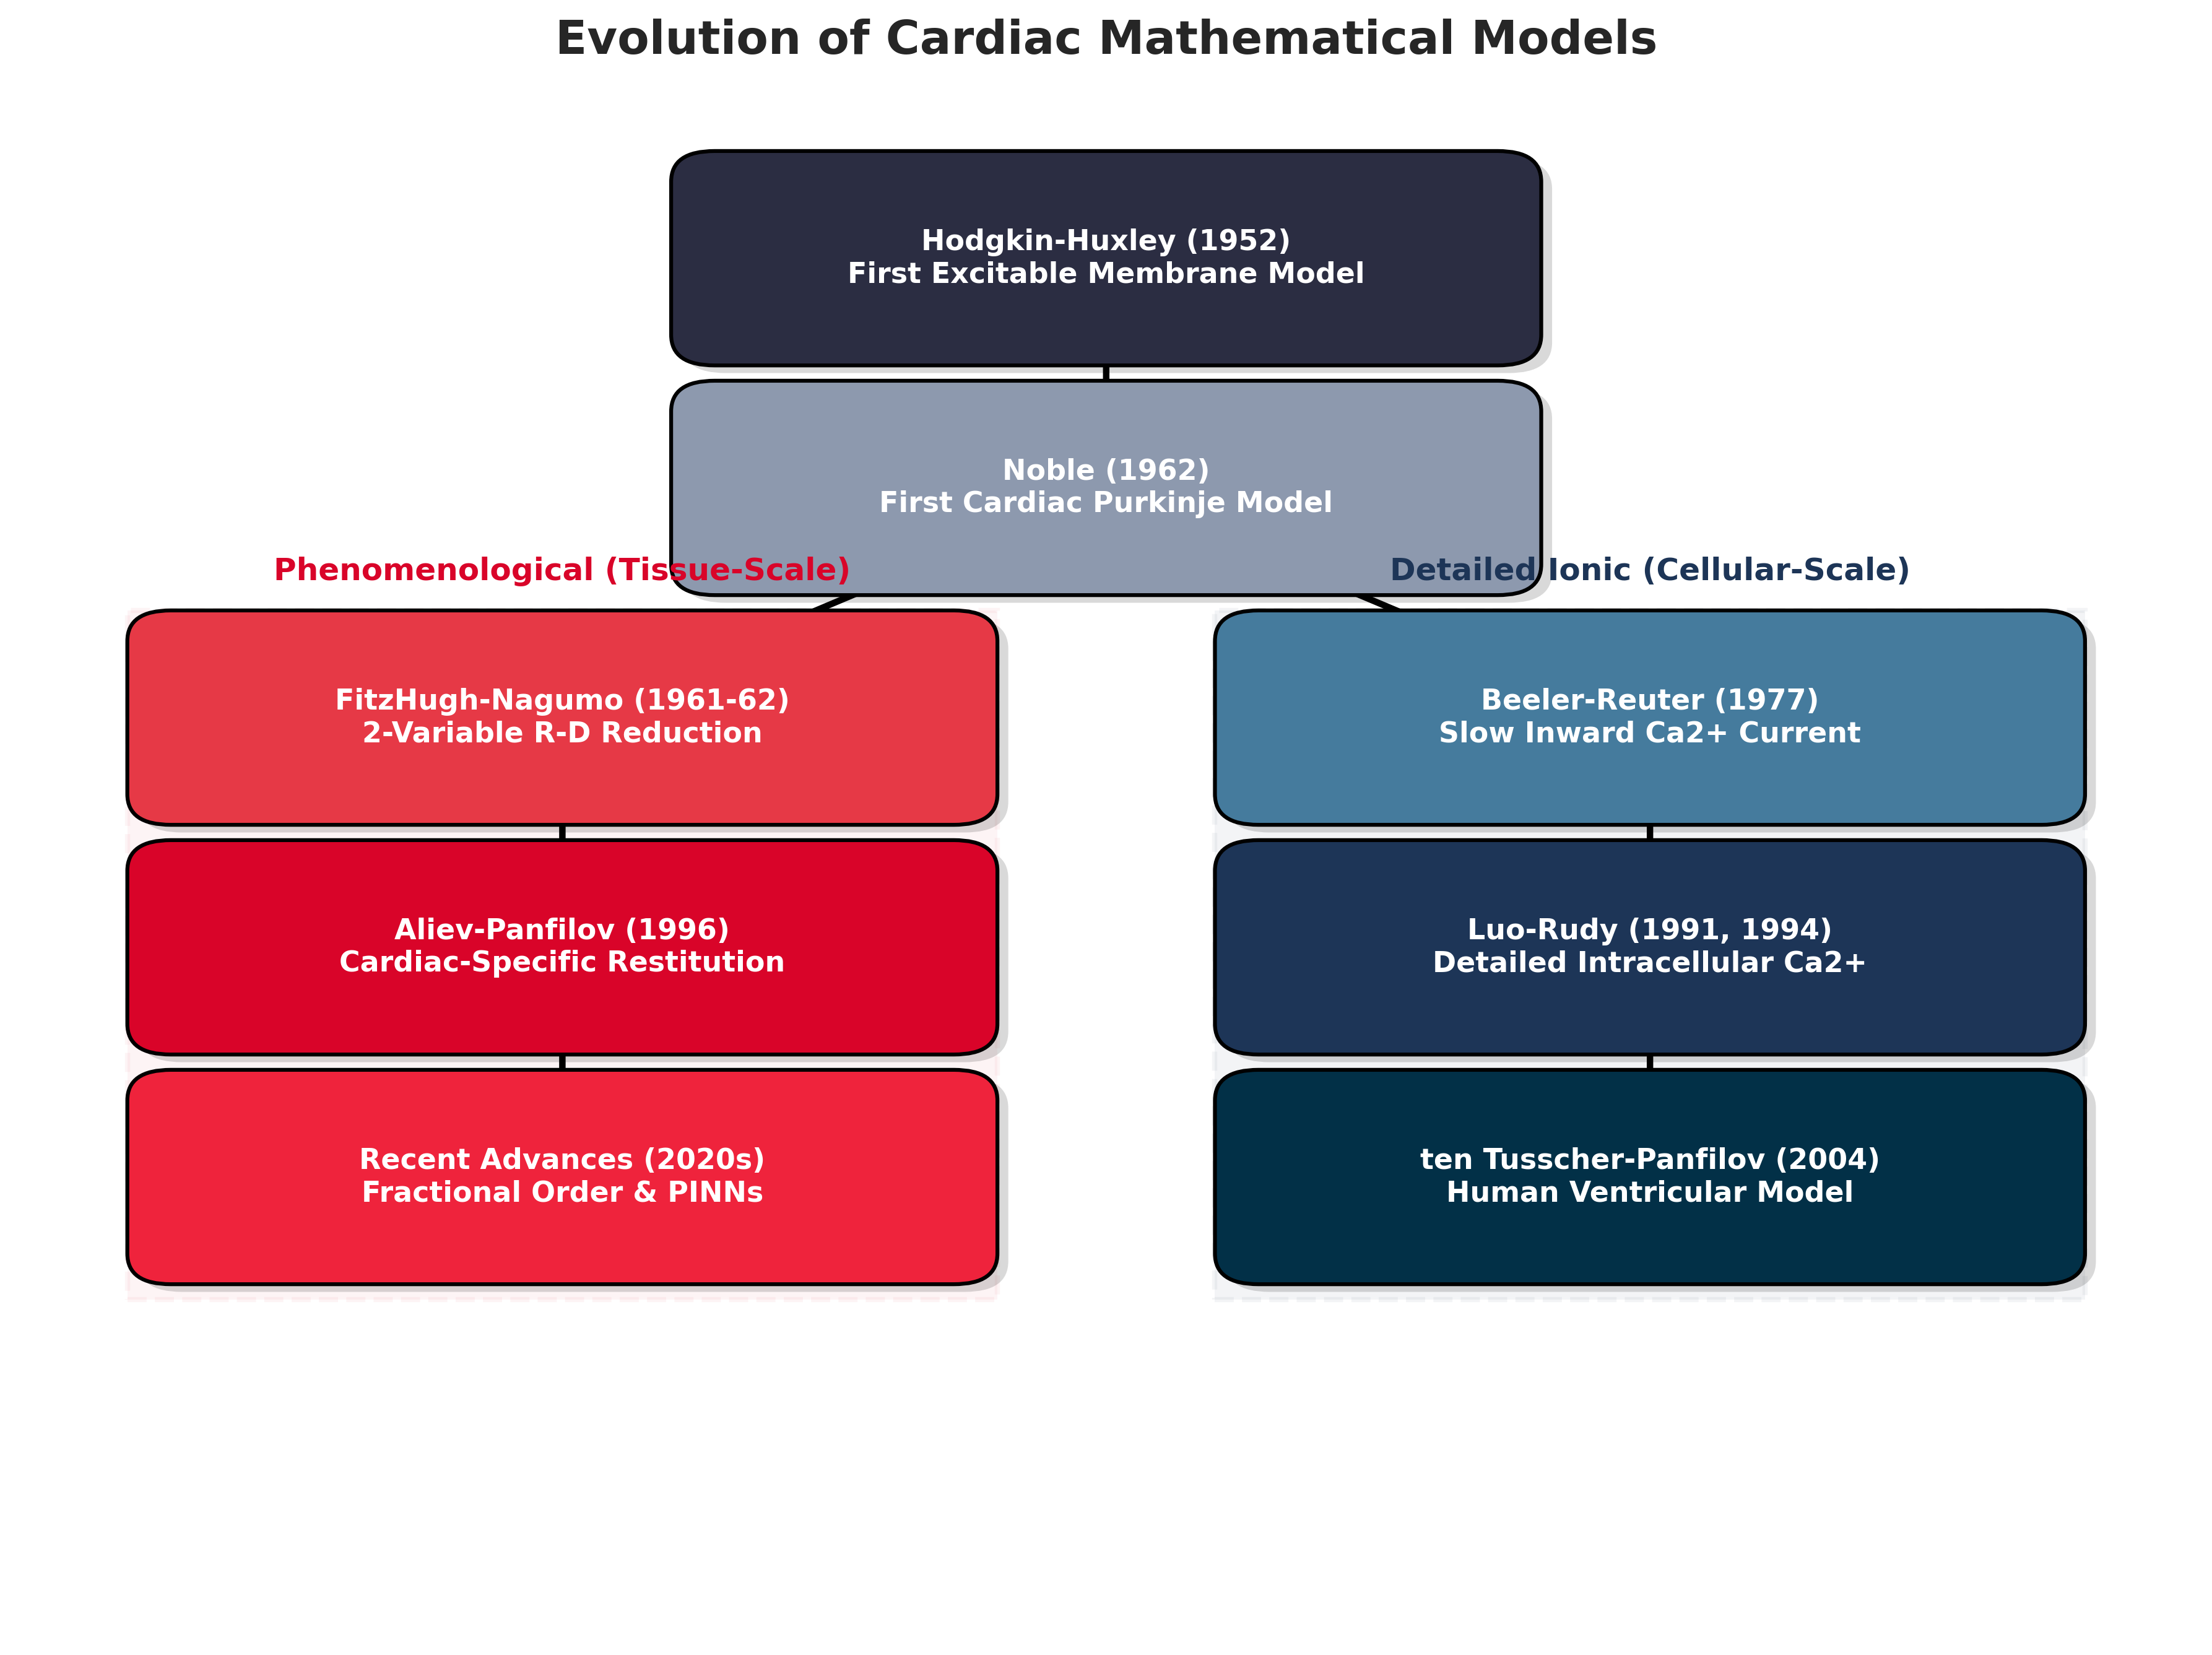

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white", context="paper")
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
ax.axis('off')

# Node configurations
nodes = {
    'HH': {'pos': (0.5, 0.9), 'text': 'Hodgkin-Huxley (1952)\nFirst Excitable Membrane Model', 'color': '#2B2D42'},
    'Noble': {'pos': (0.5, 0.75), 'text': 'Noble (1962)\nFirst Cardiac Purkinje Model', 'color': '#8D99AE'},

    # Left Branch: Phenomenological / Macro
    'FHN': {'pos': (0.25, 0.6), 'text': 'FitzHugh-Nagumo (1961-62)\n2-Variable R-D Reduction', 'color': '#E63946'},
    'AP': {'pos': (0.25, 0.45), 'text': 'Aliev-Panfilov (1996)\nCardiac-Specific Restitution', 'color': '#D90429'},
    'Recent': {'pos': (0.25, 0.3), 'text': 'Recent Advances (2020s)\nFractional Order & PINNs', 'color': '#EF233C'},

    # Right Branch: Detailed Ionic / Micro
    'BR': {'pos': (0.75, 0.6), 'text': 'Beeler-Reuter (1977)\nSlow Inward Ca2+ Current', 'color': '#457B9D'},
    'LR': {'pos': (0.75, 0.45), 'text': 'Luo-Rudy (1991, 1994)\nDetailed Intracellular Ca2+', 'color': '#1D3557'},
    'TTP': {'pos': (0.75, 0.3), 'text': 'ten Tusscher-Panfilov (2004)\nHuman Ventricular Model', 'color': '#023047'}
}

# Drawing function
def draw_node(ax, pos, text, color):
    x, y = pos
    box = mpatches.FancyBboxPatch((x - 0.18, y - 0.05), 0.36, 0.1,
                                  boxstyle="round,pad=0.02,rounding_size=0.02",
                                  edgecolor='black', facecolor=color, lw=1.5, zorder=3)
    # Drop shadow
    shadow = mpatches.FancyBboxPatch((x - 0.175, y - 0.055), 0.36, 0.1,
                                     boxstyle="round,pad=0.02,rounding_size=0.02",
                                     facecolor='black', alpha=0.15, edgecolor='none', zorder=2)
    ax.add_patch(shadow)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', color='white', fontsize=11, fontweight='bold', zorder=4)

def draw_link(ax, pos1, pos2, style="->"):
    ax.annotate("", xy=pos2, xycoords='data', xytext=pos1, textcoords='data',
                arrowprops=dict(arrowstyle=style, color="black", lw=2.5, shrinkA=18, shrinkB=18), zorder=1)

# Render
for key, node in nodes.items():
    draw_node(ax, node['pos'], node['text'], node['color'])

draw_link(ax, nodes['HH']['pos'], nodes['Noble']['pos'])
draw_link(ax, nodes['Noble']['pos'], nodes['FHN']['pos'])
draw_link(ax, nodes['Noble']['pos'], nodes['BR']['pos'])
draw_link(ax, nodes['FHN']['pos'], nodes['AP']['pos'])
draw_link(ax, nodes['AP']['pos'], nodes['Recent']['pos'])
draw_link(ax, nodes['BR']['pos'], nodes['LR']['pos'])
draw_link(ax, nodes['LR']['pos'], nodes['TTP']['pos'])

# Background bounding boxes for branches
ax.add_patch(mpatches.Rectangle((0.05, 0.22), 0.4, 0.45, fill=True, color='#E63946', alpha=0.05, zorder=0, lw=2, ls='--'))
ax.text(0.25, 0.69, "Phenomenological (Tissue-Scale)", ha='center', fontsize=12, fontweight='bold', color='#D90429')

ax.add_patch(mpatches.Rectangle((0.55, 0.22), 0.4, 0.45, fill=True, color='#1D3557', alpha=0.05, zorder=0, lw=2, ls='--'))
ax.text(0.75, 0.69, "Detailed Ionic (Cellular-Scale)", ha='center', fontsize=12, fontweight='bold', color='#1D3557')

ax.set_title("Evolution of Cardiac Mathematical Models", fontsize=18, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("Figure_2_3_Model_Evolution.png")
plt.show()

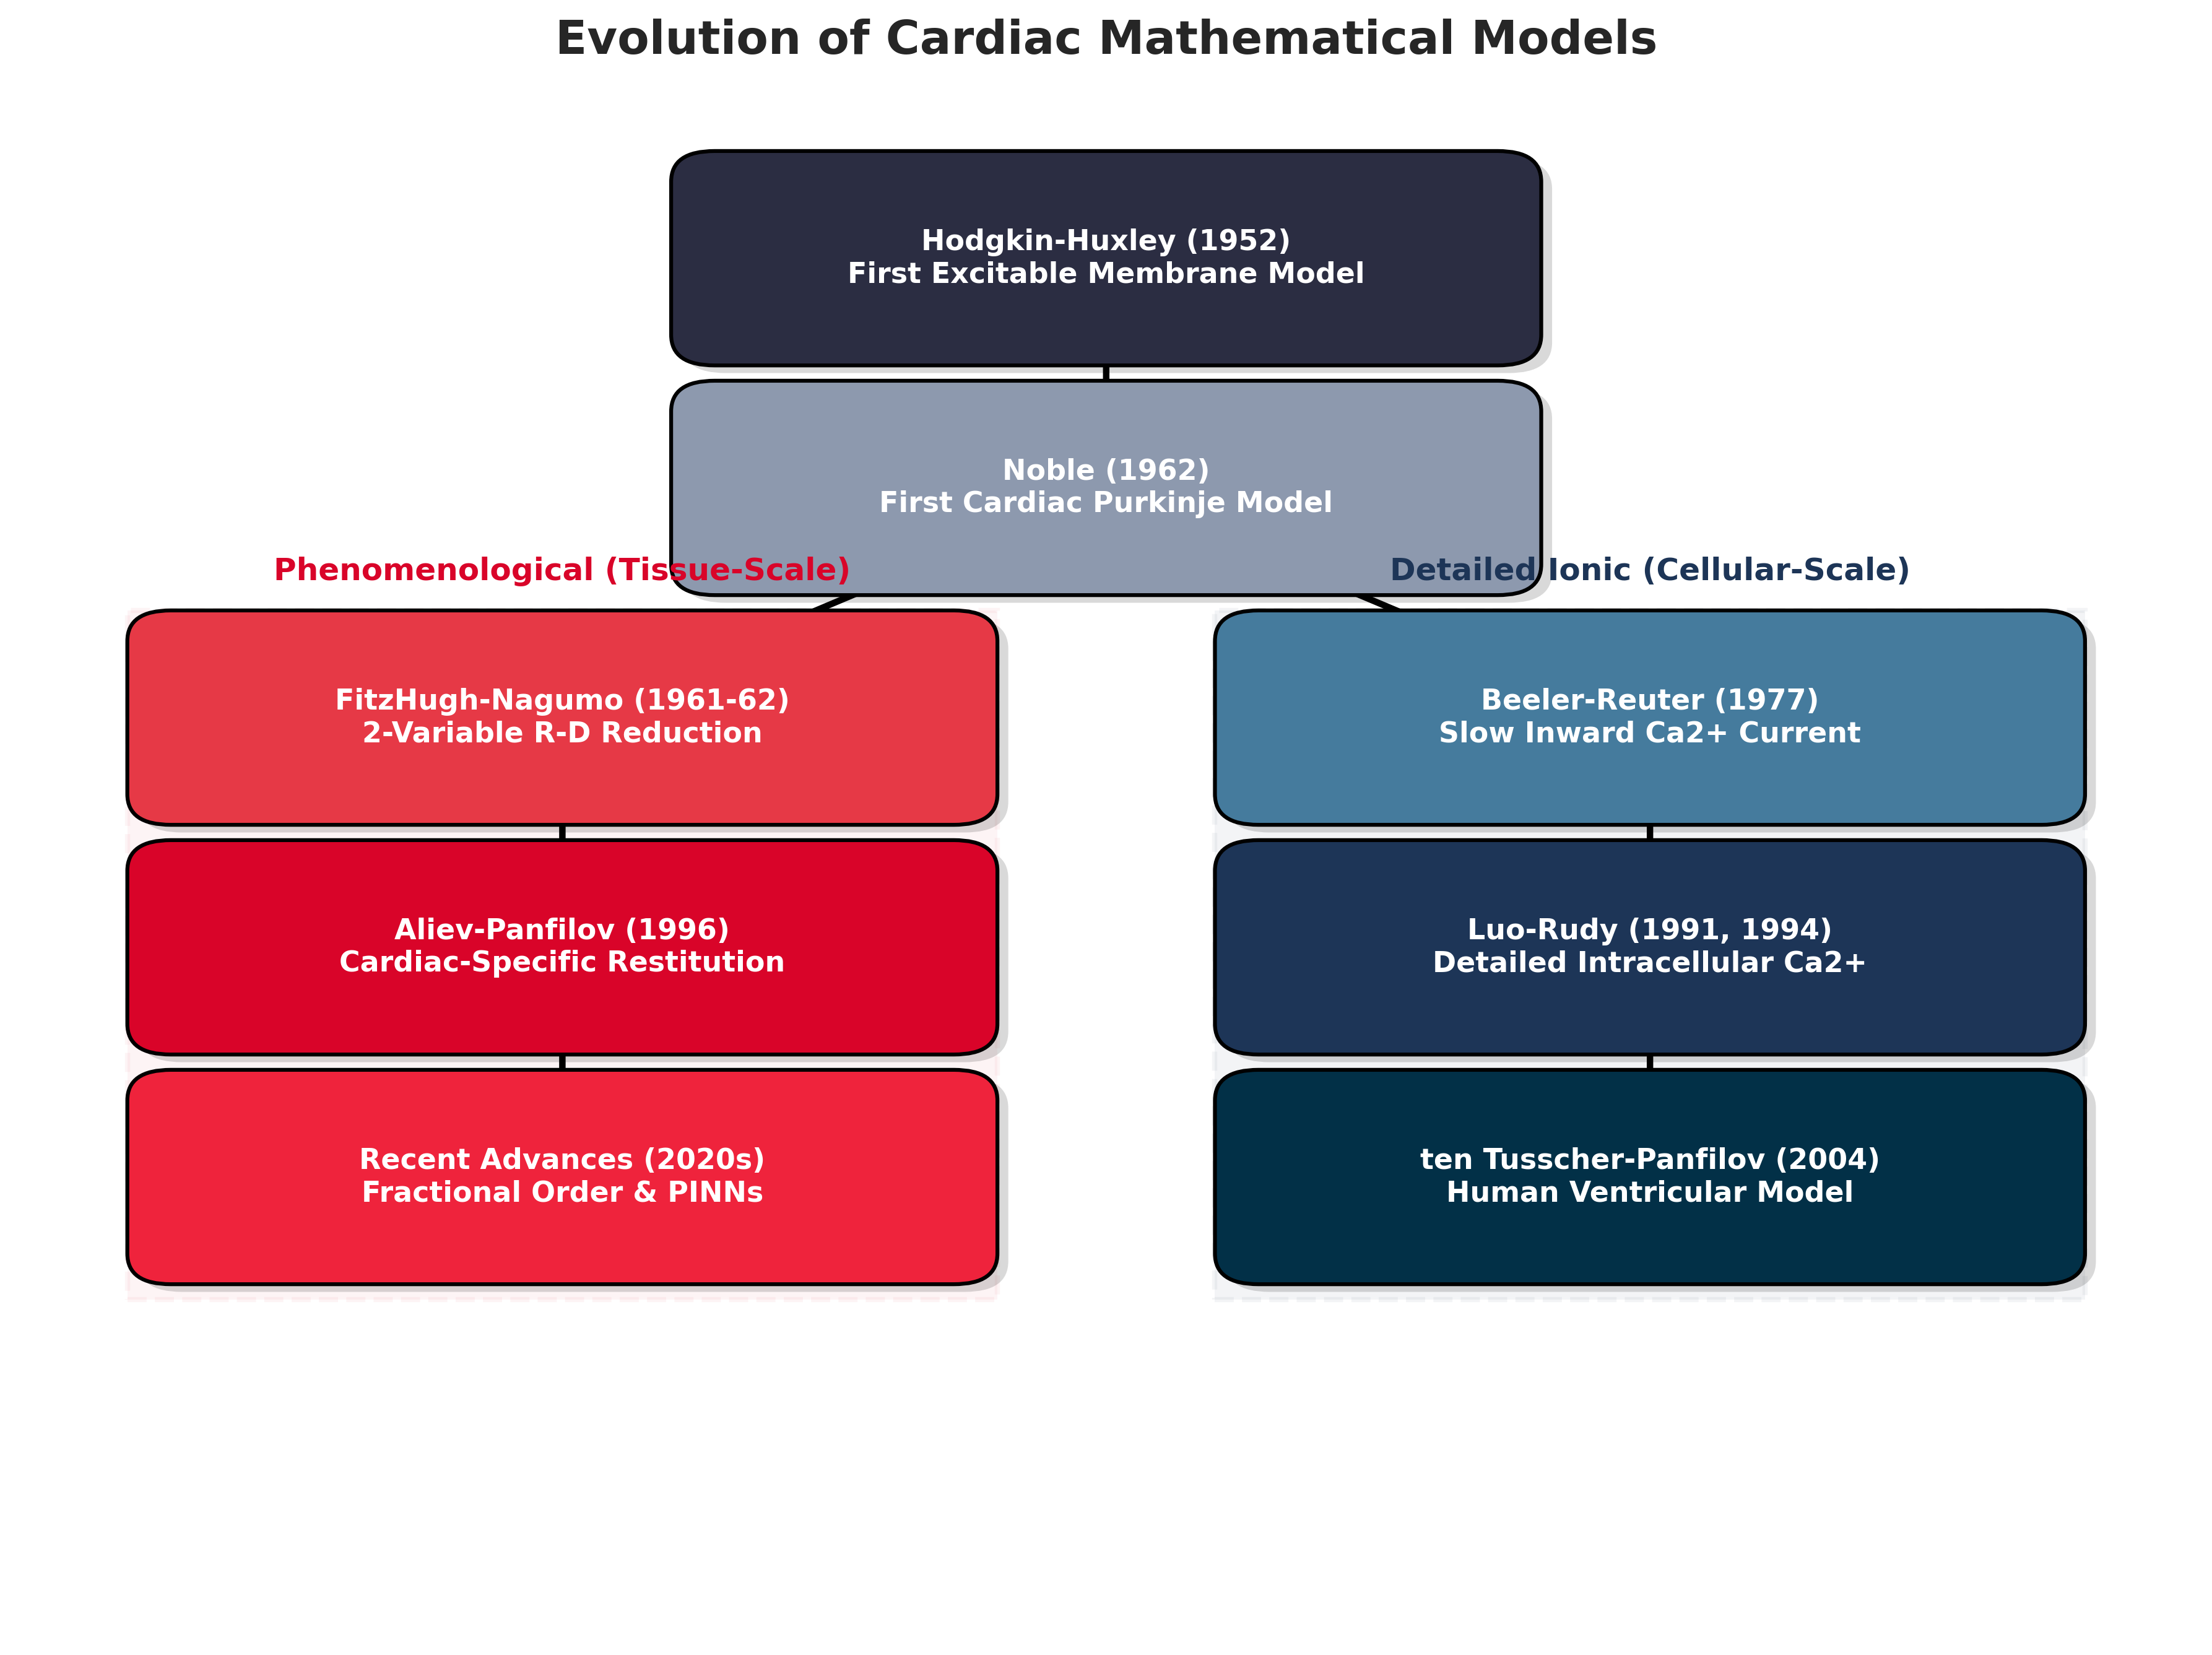

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white", context="paper")
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
ax.axis('off')

# Node configurations
nodes = {
    'HH': {'pos': (0.5, 0.9), 'text': 'Hodgkin-Huxley (1952)\nFirst Excitable Membrane Model', 'color': '#2B2D42'},
    'Noble': {'pos': (0.5, 0.75), 'text': 'Noble (1962)\nFirst Cardiac Purkinje Model', 'color': '#8D99AE'},

    # Left Branch: Phenomenological / Macro
    'FHN': {'pos': (0.25, 0.6), 'text': 'FitzHugh-Nagumo (1961-62)\n2-Variable R-D Reduction', 'color': '#E63946'},
    'AP': {'pos': (0.25, 0.45), 'text': 'Aliev-Panfilov (1996)\nCardiac-Specific Restitution', 'color': '#D90429'},
    'Recent': {'pos': (0.25, 0.3), 'text': 'Recent Advances (2020s)\nFractional Order & PINNs', 'color': '#EF233C'},

    # Right Branch: Detailed Ionic / Micro
    'BR': {'pos': (0.75, 0.6), 'text': 'Beeler-Reuter (1977)\nSlow Inward Ca2+ Current', 'color': '#457B9D'},
    'LR': {'pos': (0.75, 0.45), 'text': 'Luo-Rudy (1991, 1994)\nDetailed Intracellular Ca2+', 'color': '#1D3557'},
    'TTP': {'pos': (0.75, 0.3), 'text': 'ten Tusscher-Panfilov (2004)\nHuman Ventricular Model', 'color': '#023047'}
}

# Drawing function
def draw_node(ax, pos, text, color):
    x, y = pos
    box = mpatches.FancyBboxPatch((x - 0.18, y - 0.05), 0.36, 0.1,
                                  boxstyle="round,pad=0.02,rounding_size=0.02",
                                  edgecolor='black', facecolor=color, lw=1.5, zorder=3)
    # Drop shadow
    shadow = mpatches.FancyBboxPatch((x - 0.175, y - 0.055), 0.36, 0.1,
                                     boxstyle="round,pad=0.02,rounding_size=0.02",
                                     facecolor='black', alpha=0.15, edgecolor='none', zorder=2)
    ax.add_patch(shadow)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', color='white', fontsize=11, fontweight='bold', zorder=4)

def draw_link(ax, pos1, pos2, style="->"):
    ax.annotate("", xy=pos2, xycoords='data', xytext=pos1, textcoords='data',
                arrowprops=dict(arrowstyle=style, color="black", lw=2.5, shrinkA=18, shrinkB=18), zorder=1)

# Render
for key, node in nodes.items():
    draw_node(ax, node['pos'], node['text'], node['color'])

draw_link(ax, nodes['HH']['pos'], nodes['Noble']['pos'])
draw_link(ax, nodes['Noble']['pos'], nodes['FHN']['pos'])
draw_link(ax, nodes['Noble']['pos'], nodes['BR']['pos'])
draw_link(ax, nodes['FHN']['pos'], nodes['AP']['pos'])
draw_link(ax, nodes['AP']['pos'], nodes['Recent']['pos'])
draw_link(ax, nodes['BR']['pos'], nodes['LR']['pos'])
draw_link(ax, nodes['LR']['pos'], nodes['TTP']['pos'])

# Background bounding boxes for branches
ax.add_patch(mpatches.Rectangle((0.05, 0.22), 0.4, 0.45, fill=True, color='#E63946', alpha=0.05, zorder=0, lw=2, ls='--'))
ax.text(0.25, 0.69, "Phenomenological (Tissue-Scale)", ha='center', fontsize=12, fontweight='bold', color='#D90429')

ax.add_patch(mpatches.Rectangle((0.55, 0.22), 0.4, 0.45, fill=True, color='#1D3557', alpha=0.05, zorder=0, lw=2, ls='--'))
ax.text(0.75, 0.69, "Detailed Ionic (Cellular-Scale)", ha='center', fontsize=12, fontweight='bold', color='#1D3557')

ax.set_title("Evolution of Cardiac Mathematical Models", fontsize=18, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("Figure_2_3_Model_Evolution.png")
plt.show()

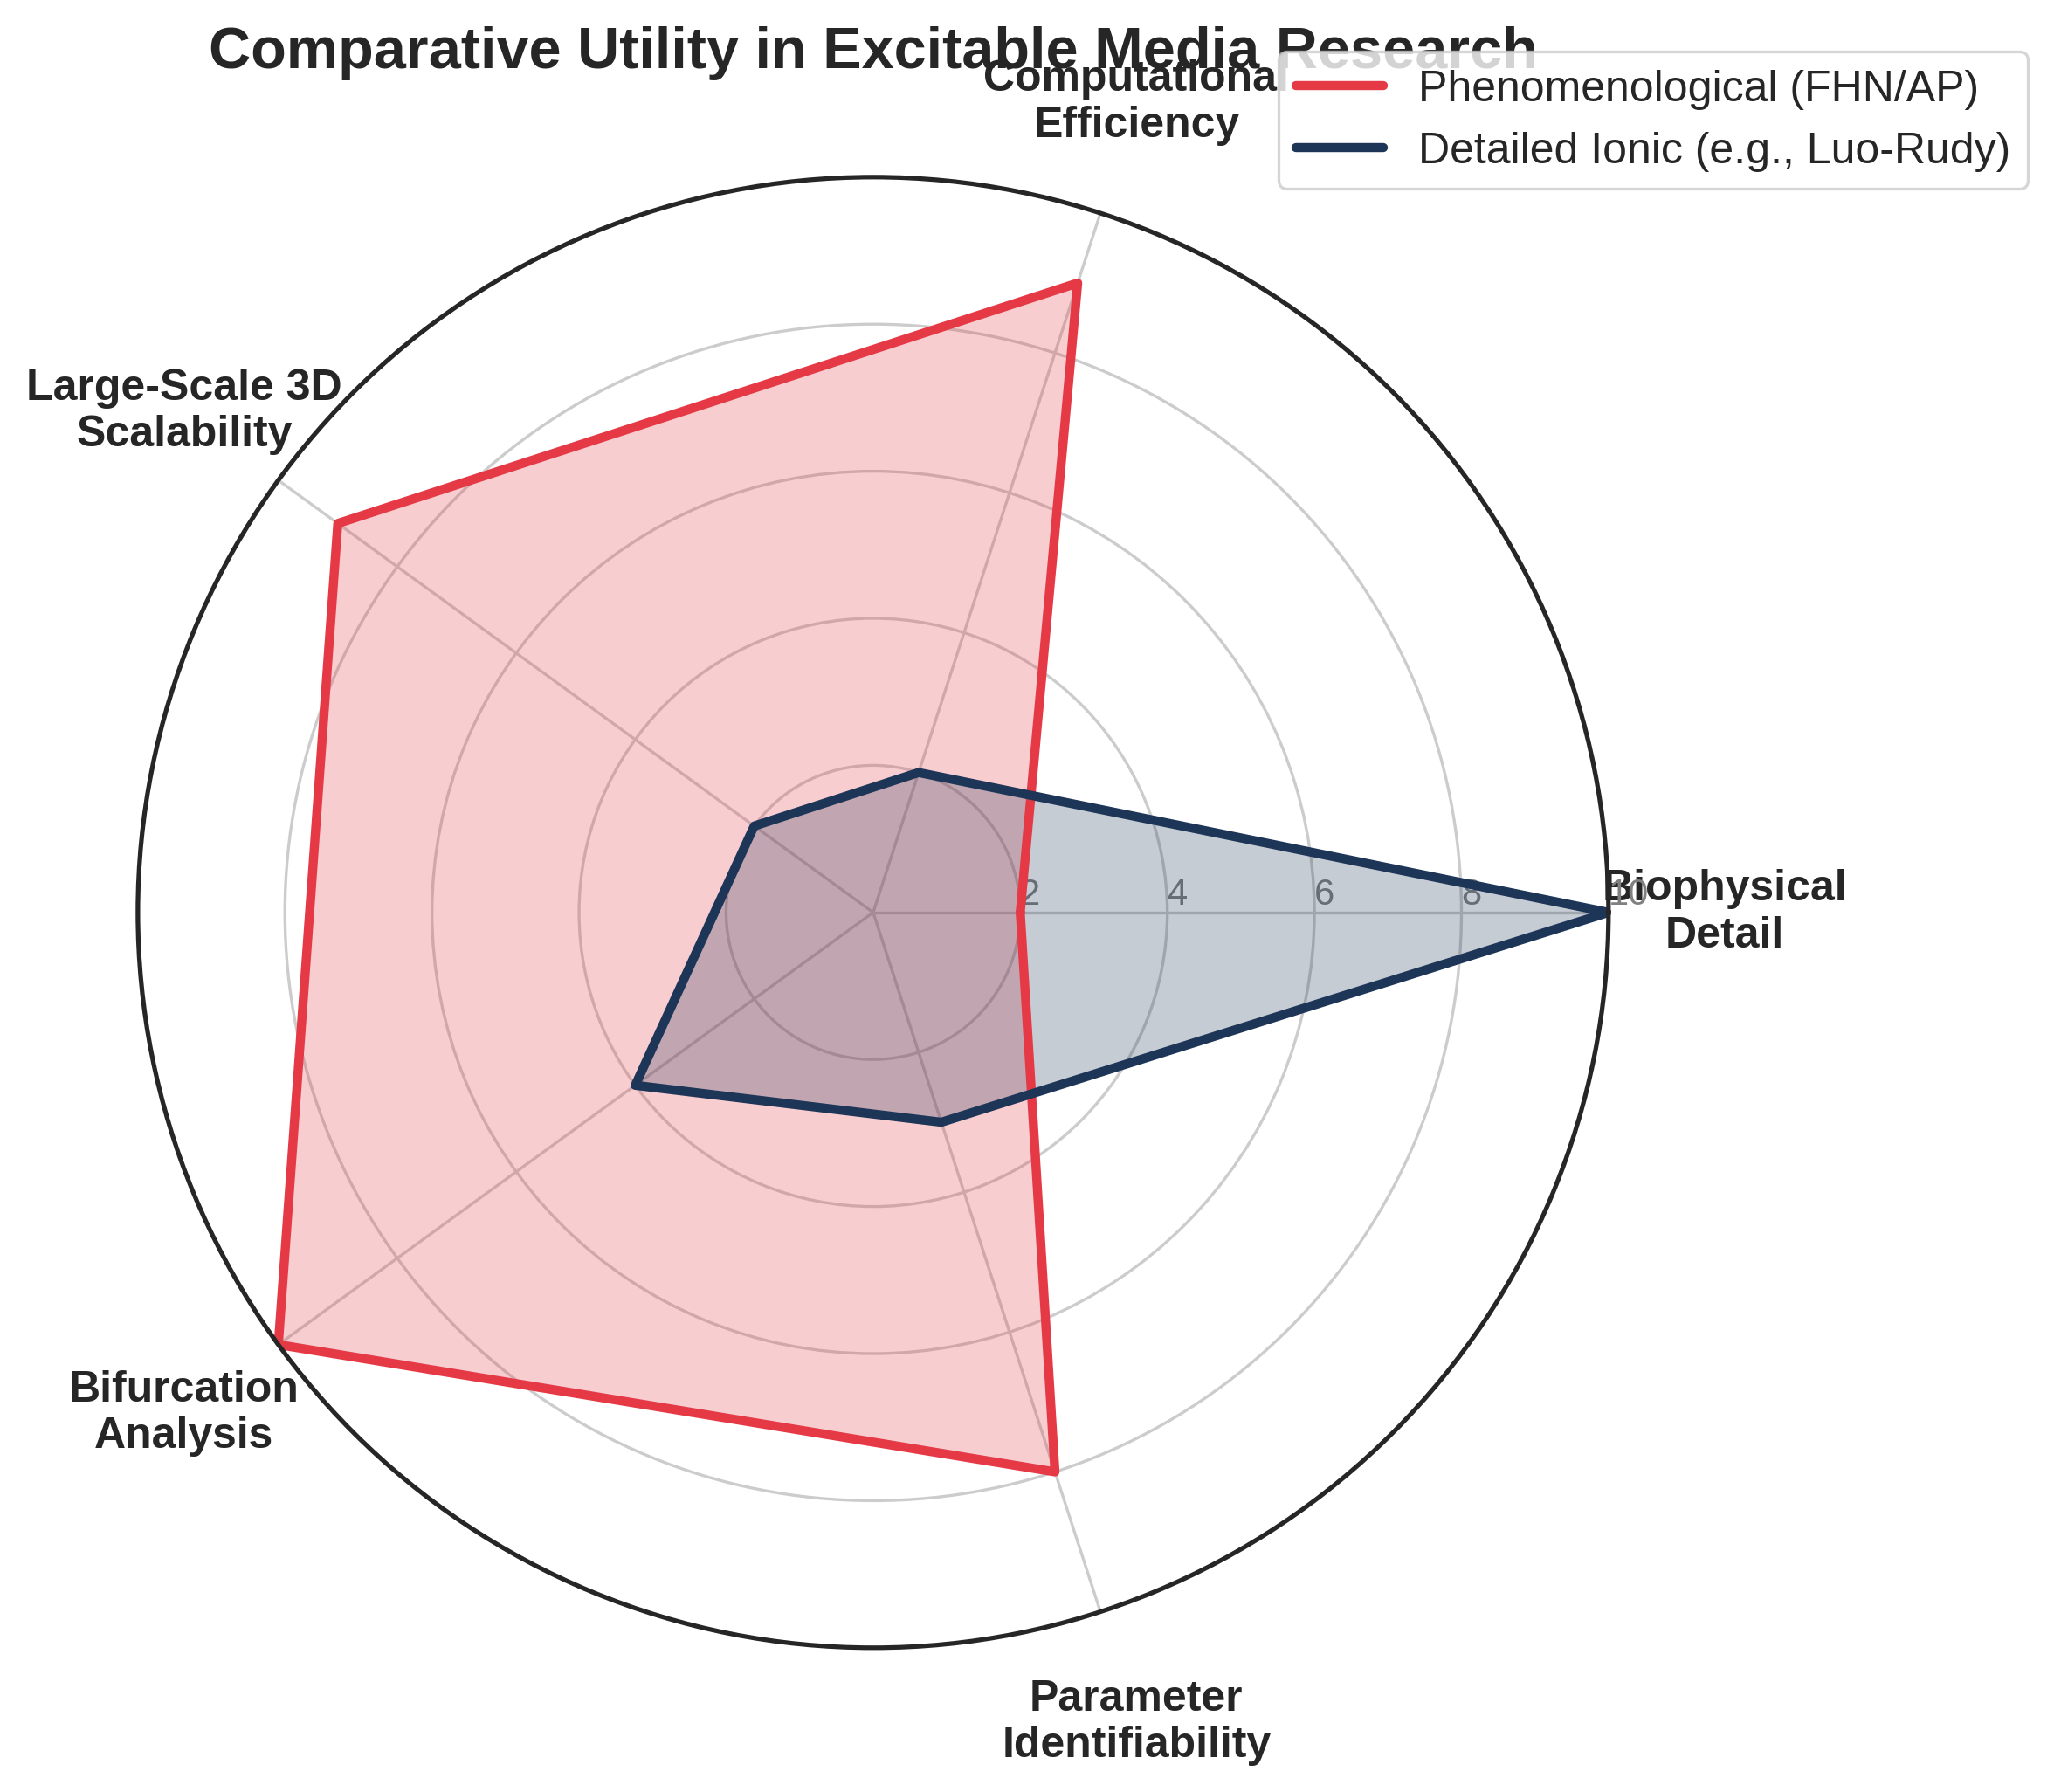

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

labels = np.array(['Biophysical\nDetail', 'Computational\nEfficiency',
                   'Large-Scale 3D\nScalability', 'Bifurcation\nAnalysis',
                   'Parameter\nIdentifiability'])
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

# Data for FHN vs Detailed models
fhn_scores = [2, 9, 9, 10, 8]
ionic_scores = [10, 2, 2, 4, 3]

fhn_scores += fhn_scores[:1]
ionic_scores += ionic_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=300)

# Draw one axe per variable and add labels
plt.xticks(angles[:-1], labels, size=12, fontweight='bold')
ax.tick_params(pad=25)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([2, 4, 6, 8, 10], ["2", "4", "6", "8", "10"], color="grey", size=10)
plt.ylim(0, 10)

# Plot FHN
ax.plot(angles, fhn_scores, color='#E63946', linewidth=2.5, linestyle='solid', label='Phenomenological (FHN/AP)')
ax.fill(angles, fhn_scores, color='#E63946', alpha=0.25)

# Plot Detailed Ionic
ax.plot(angles, ionic_scores, color='#1D3557', linewidth=2.5, linestyle='solid', label='Detailed Ionic (e.g., Luo-Rudy)')
ax.fill(angles, ionic_scores, color='#1D3557', alpha=0.25)

ax.set_title("Comparative Utility in Excitable Media Research", size=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=True, fontsize=12)

plt.tight_layout()
plt.savefig("Figure_2_4_Radar_Comparison.png")
plt.show()

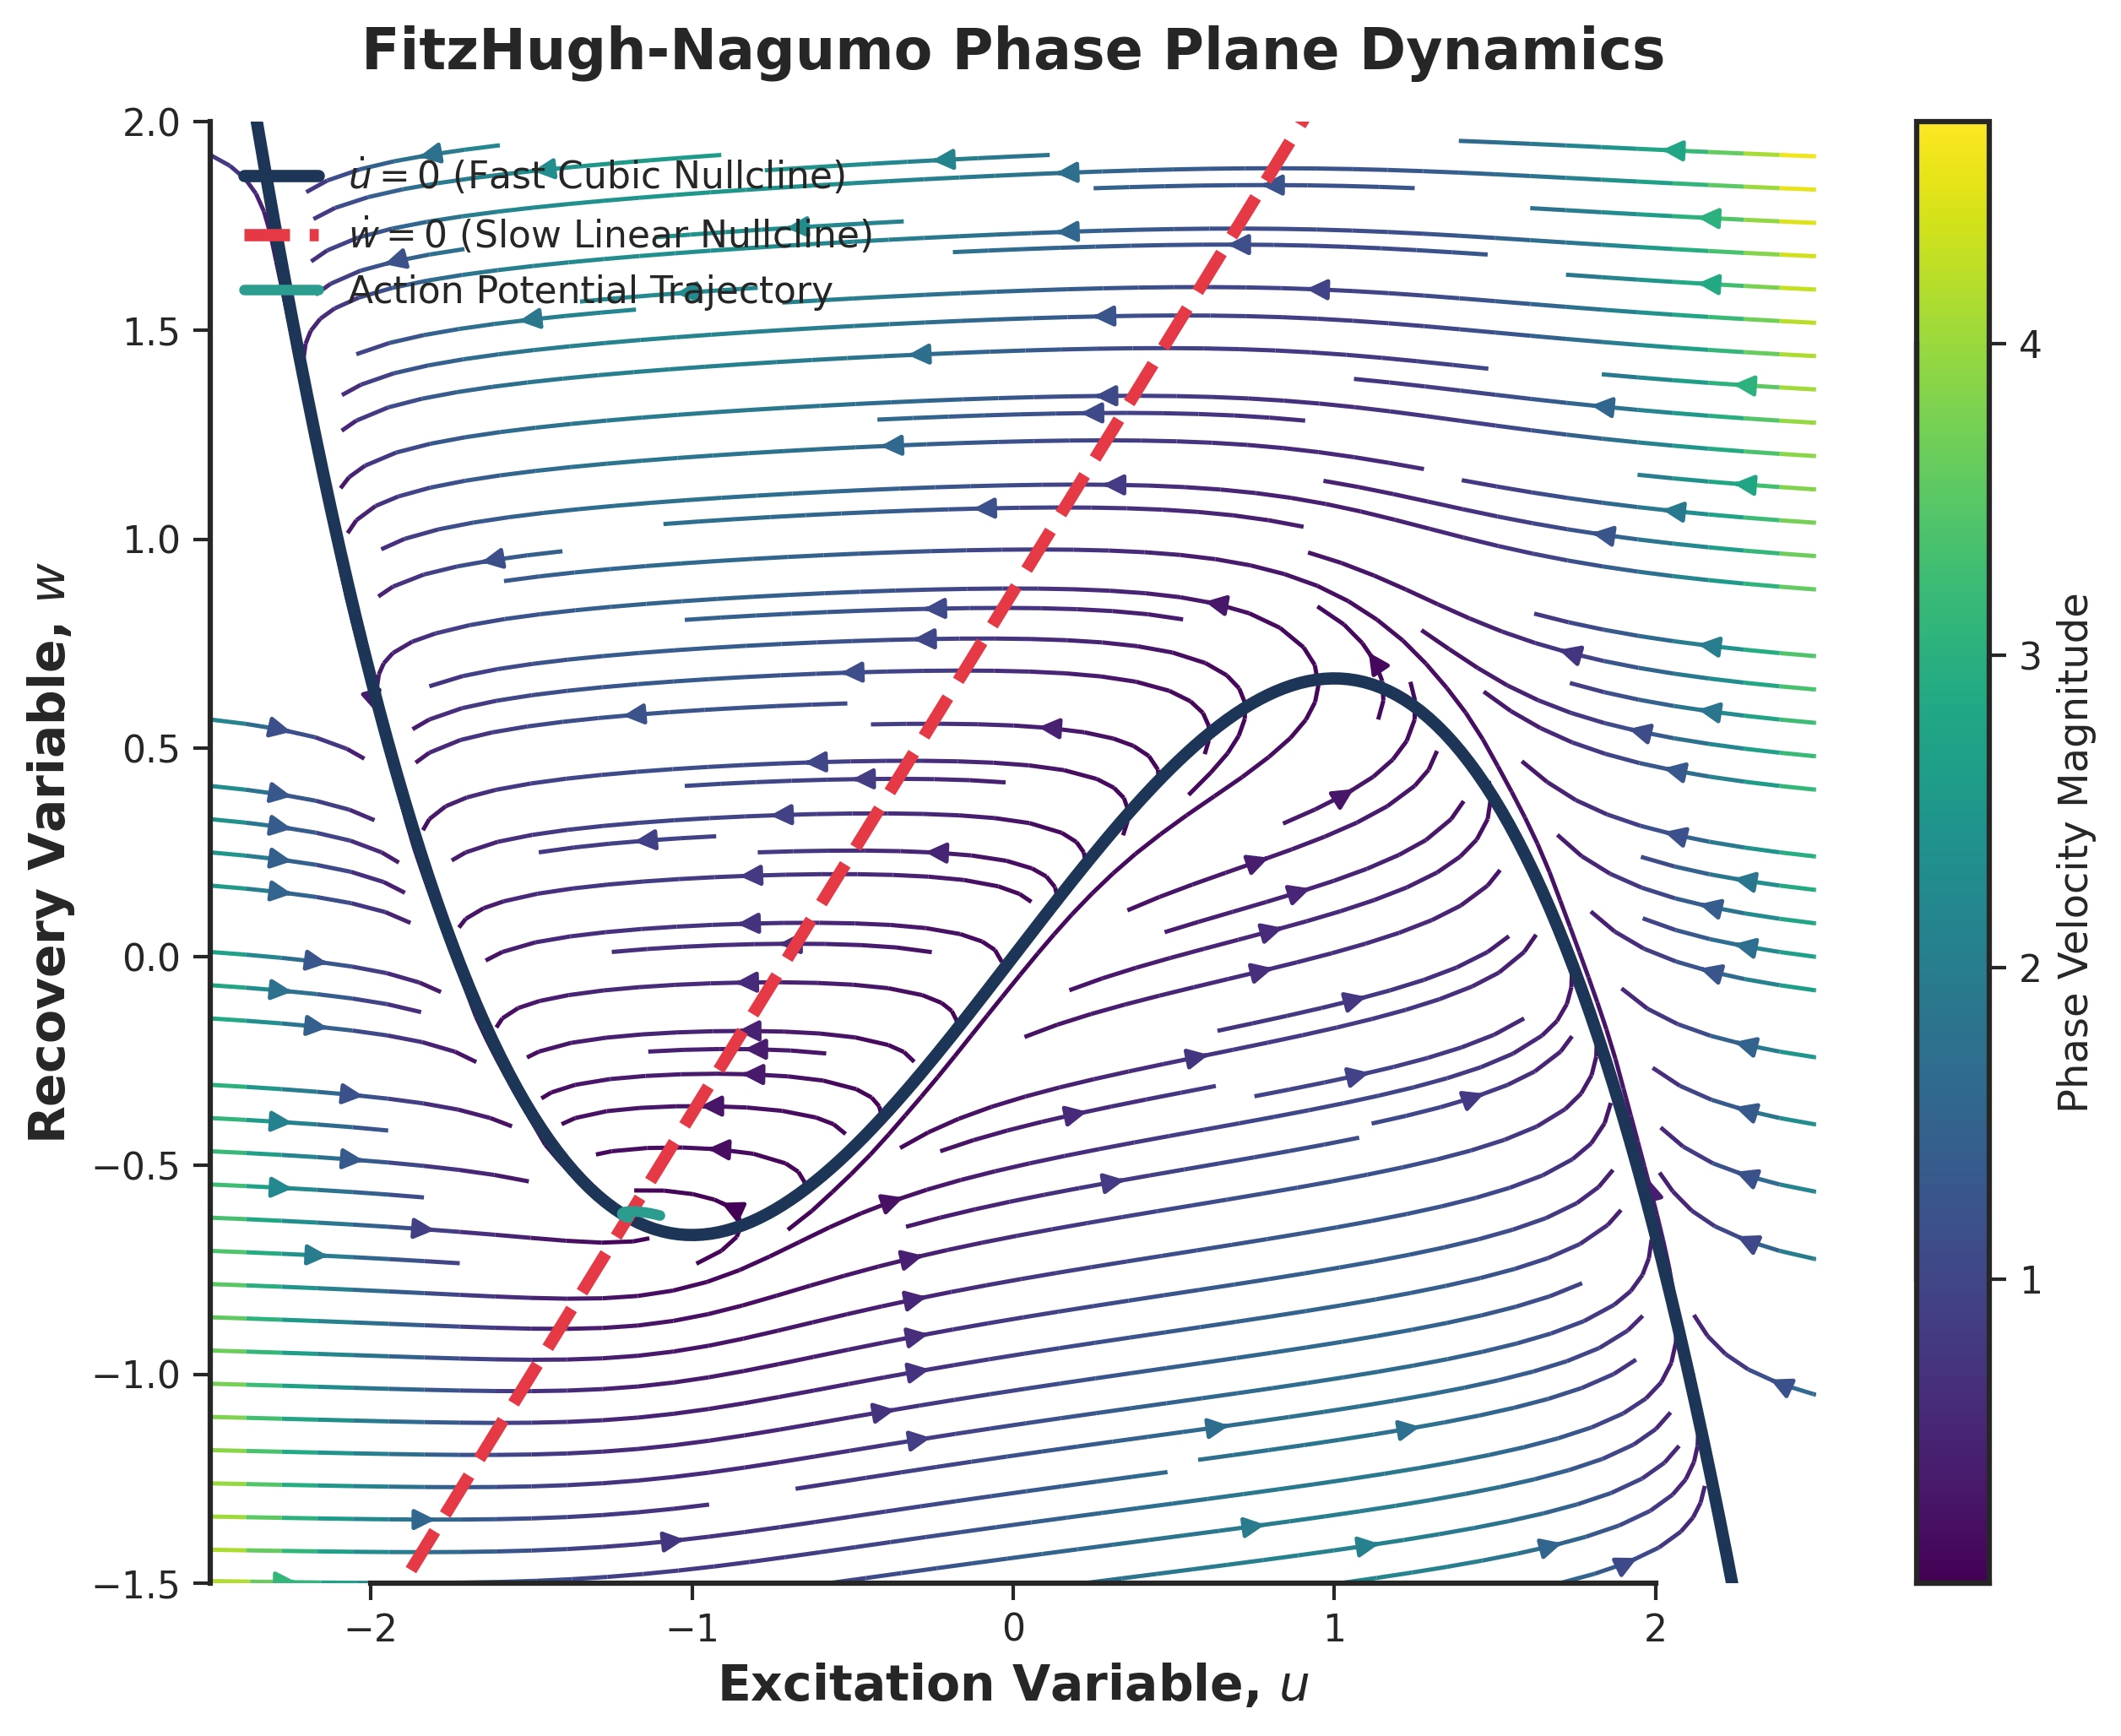

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Advanced Aesthetics
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.5

# FHN Parameters
eps = 0.08
a = 0.7
b = 0.8
I_ext = 0.0

# Grid for vector field
u = np.linspace(-2.5, 2.5, 25)
w = np.linspace(-1.5, 2.0, 25)
U, W = np.meshgrid(u, w)

# FHN ODEs
dUdt = U - (U**3)/3 - W + I_ext
dWdt = eps * (U + a - b * W)

fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# Streamplot for vector field
strm = ax.streamplot(U, W, dUdt, dWdt, color=np.sqrt(dUdt**2 + dWdt**2),
                     cmap='viridis', linewidth=1.2, density=1.5, arrowsize=1.2)
fig.colorbar(strm.lines, ax=ax, label='Phase Velocity Magnitude')

# Nullclines
u_null_x = np.linspace(-2.5, 2.5, 200)
u_null_y = u_null_x - (u_null_x**3)/3 + I_ext
w_null_x = np.linspace(-2.5, 2.5, 200)
w_null_y = (w_null_x + a) / b

ax.plot(u_null_x, u_null_y, '#1D3557', lw=3.5, label=r'$\dot{u} = 0$ (Fast Cubic Nullcline)')
ax.plot(w_null_x, w_null_y, '#E63946', lw=3.5, linestyle='--', label=r'$\dot{w} = 0$ (Slow Linear Nullcline)')

# Trajectory Simulation (Suprathreshold)
t = np.linspace(0, 100, 5000)
u_traj, w_traj = [-1.1], [-0.62] # Resting is approx (-1.2, -0.62), perturb u to -1.1

dt = t[1] - t[0]
for _ in range(len(t)-1):
    ui, wi = u_traj[-1], w_traj[-1]
    du = ui - (ui**3)/3 - wi + I_ext
    dw = eps * (ui + a - b * wi)
    u_traj.append(ui + du * dt)
    w_traj.append(wi + dw * dt)

ax.plot(u_traj, w_traj, color='#2A9D8F', lw=3, label='Action Potential Trajectory')

# Formatting
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 2.0)
ax.set_xlabel(r'Excitation Variable, $u$', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Recovery Variable, $w$', fontsize=14, fontweight='bold')
ax.set_title("FitzHugh-Nagumo Phase Plane Dynamics", fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper left', framealpha=0.9, edgecolor='black')

sns.despine(trim=True)
plt.tight_layout()
plt.savefig("Figure_3_1_FHN_PhasePlane.png")
plt.show()

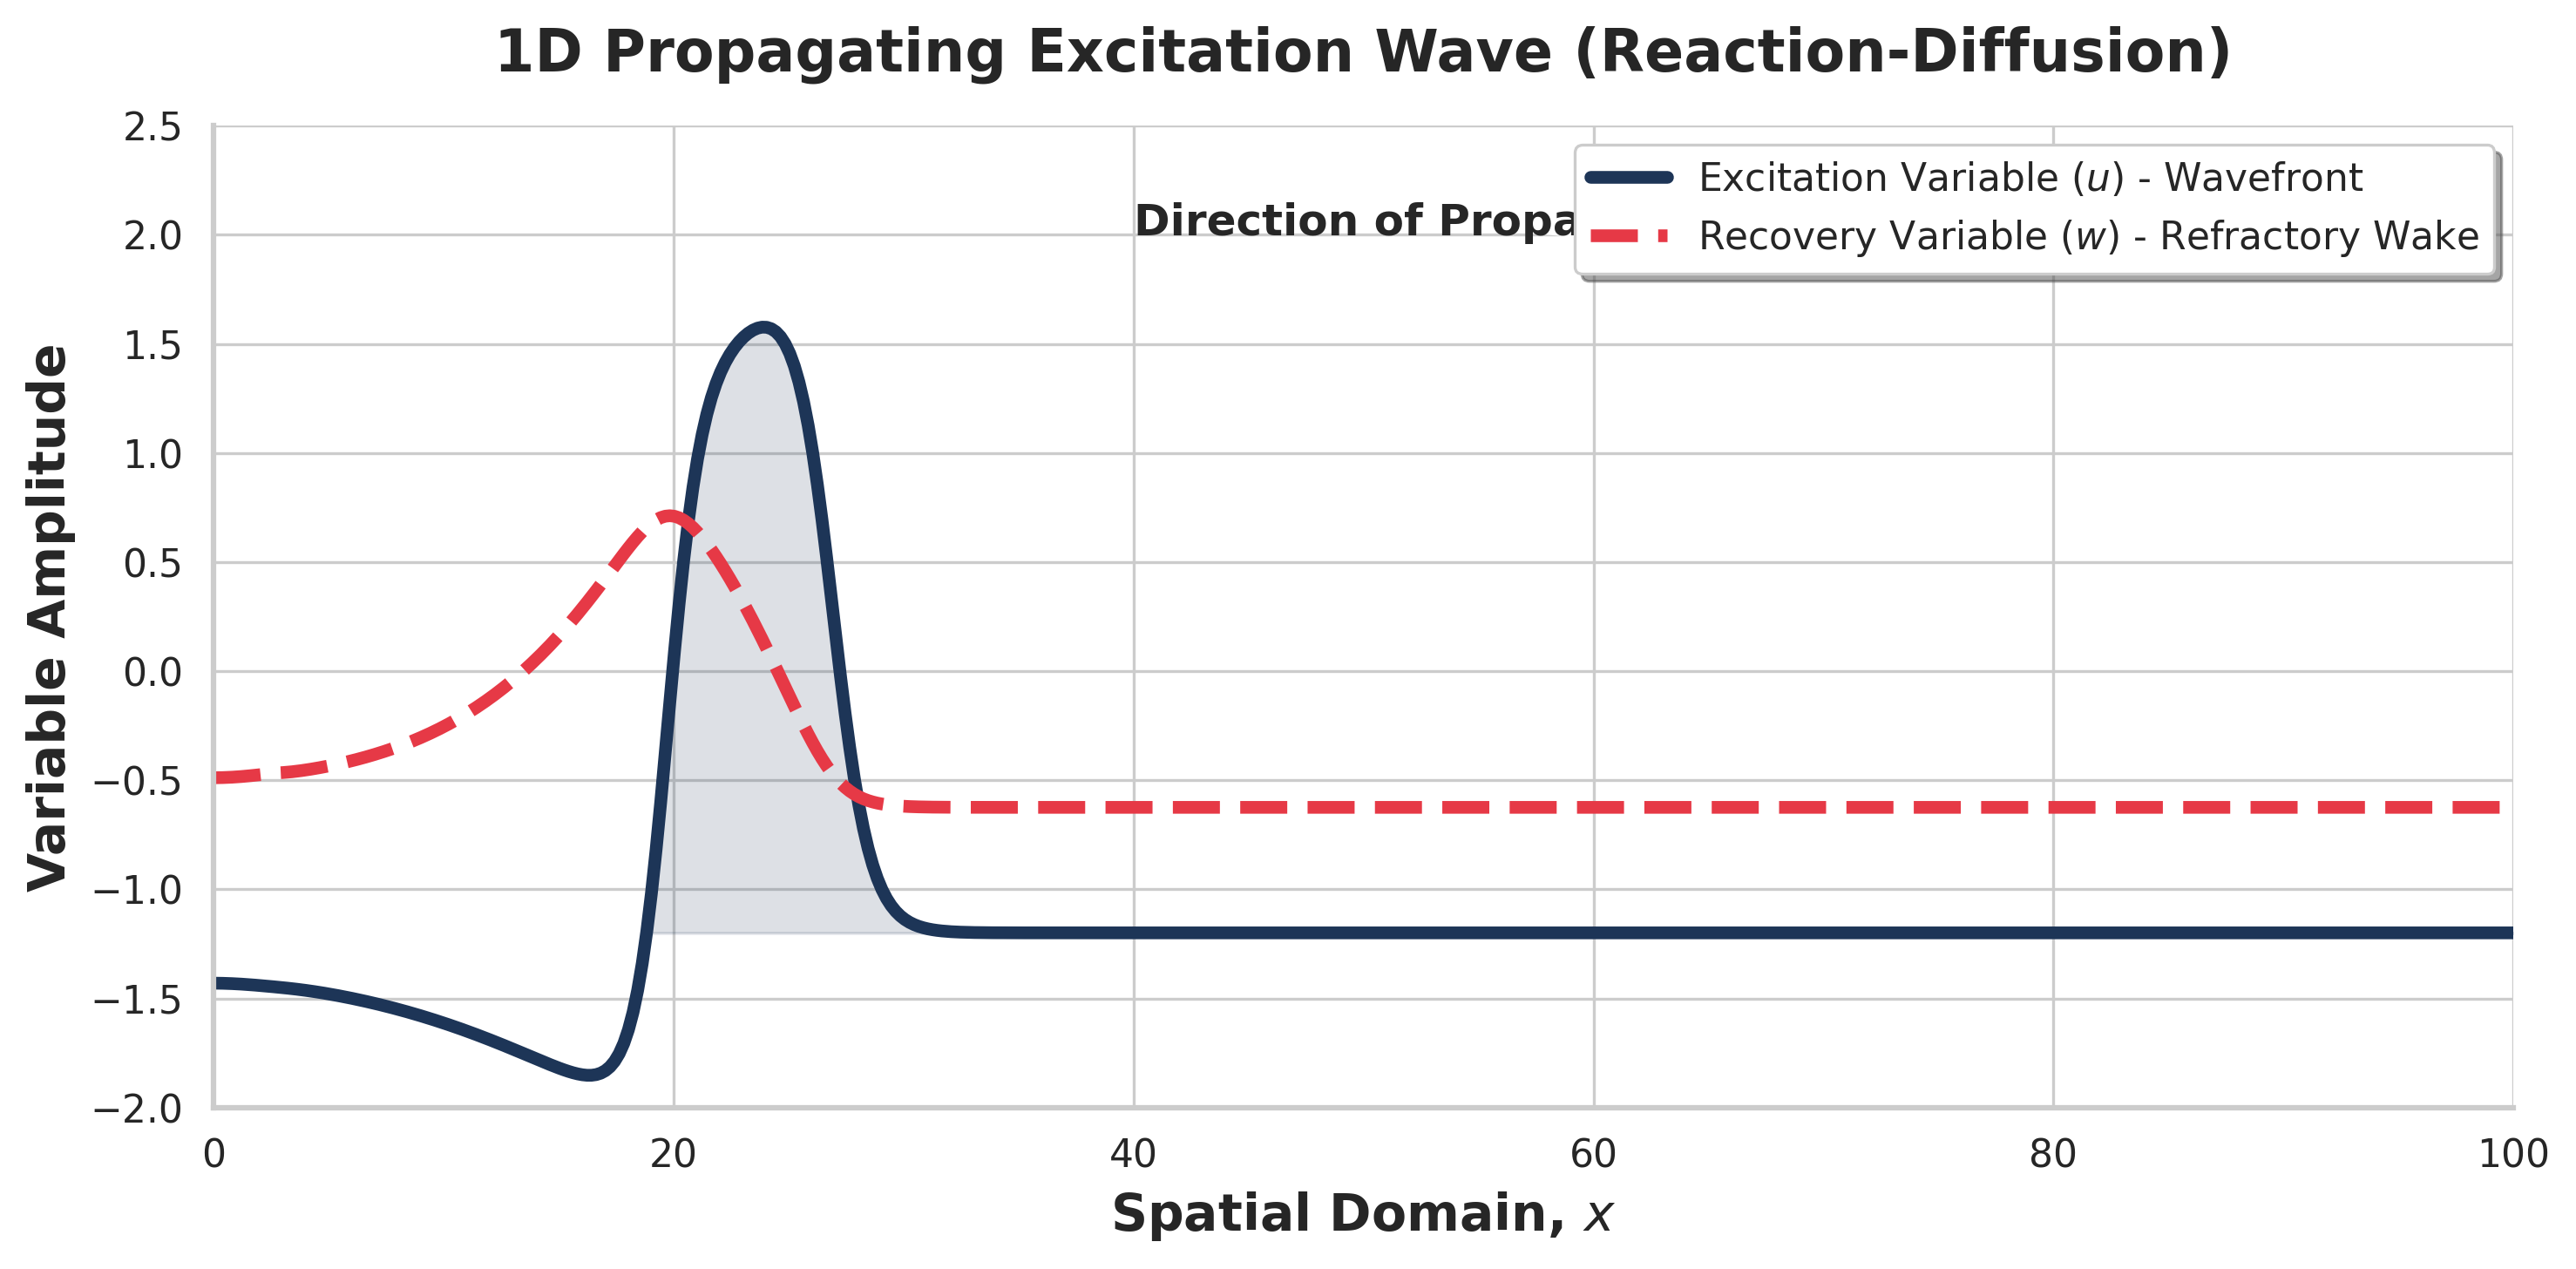

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['axes.linewidth'] = 1.5

# 1D PDE Simulation Parameters
L = 100.0         # Domain length
N = 500           # Spatial points
dx = L / N
x = np.linspace(0, L, N)
dt = 0.01
T = 30.0          # Total time
steps = int(T / dt)
D = 1.0           # Diffusion coefficient

# FHN Parameters
eps = 0.08
a = 0.7
b = 0.8

# Initialize state variables
u = np.full(N, -1.2)  # Resting state
w = np.full(N, -0.62)

# Apply stimulus at left boundary to trigger wave
u[0:15] = 1.5

# Finite Difference Euler integration
for _ in range(steps):
    # Compute Laplacian (second spatial derivative) with Neumann boundary conditions
    laplacian_u = np.zeros(N)
    laplacian_u[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    laplacian_u[0] = (u[1] - u[0]) / dx**2
    laplacian_u[-1] = (u[-2] - u[-1]) / dx**2

    # Reaction terms
    du = u - (u**3)/3 - w
    dw = eps * (u + a - b * w)

    # Update variables
    u += dt * (D * laplacian_u + du)
    w += dt * dw

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plotting the snapshot
ax.plot(x, u, color='#1D3557', lw=3.5, label=r'Excitation Variable ($u$) - Wavefront')
ax.plot(x, w, color='#E63946', lw=3.5, linestyle='--', label=r'Recovery Variable ($w$) - Refractory Wake')

# Fill under curves for aesthetic depth
ax.fill_between(x, u, -1.2, where=(u > -1.2), color='#1D3557', alpha=0.15)

# Formatting
ax.set_title("1D Propagating Excitation Wave (Reaction-Diffusion)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Spatial Domain, $x$", fontsize=14, fontweight='bold')
ax.set_ylabel("Variable Amplitude", fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(-2.0, 2.5)

# Annotations showing direction
ax.annotate('Direction of Propagation', xy=(60, 2.0), xytext=(40, 2.0),
            arrowprops=dict(facecolor='black', arrowstyle="->", lw=2),
            fontsize=12, fontweight='bold')

ax.legend(loc='upper right', frameon=True, shadow=True)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("Figure_3_2_TravellingWave.png")
plt.show()

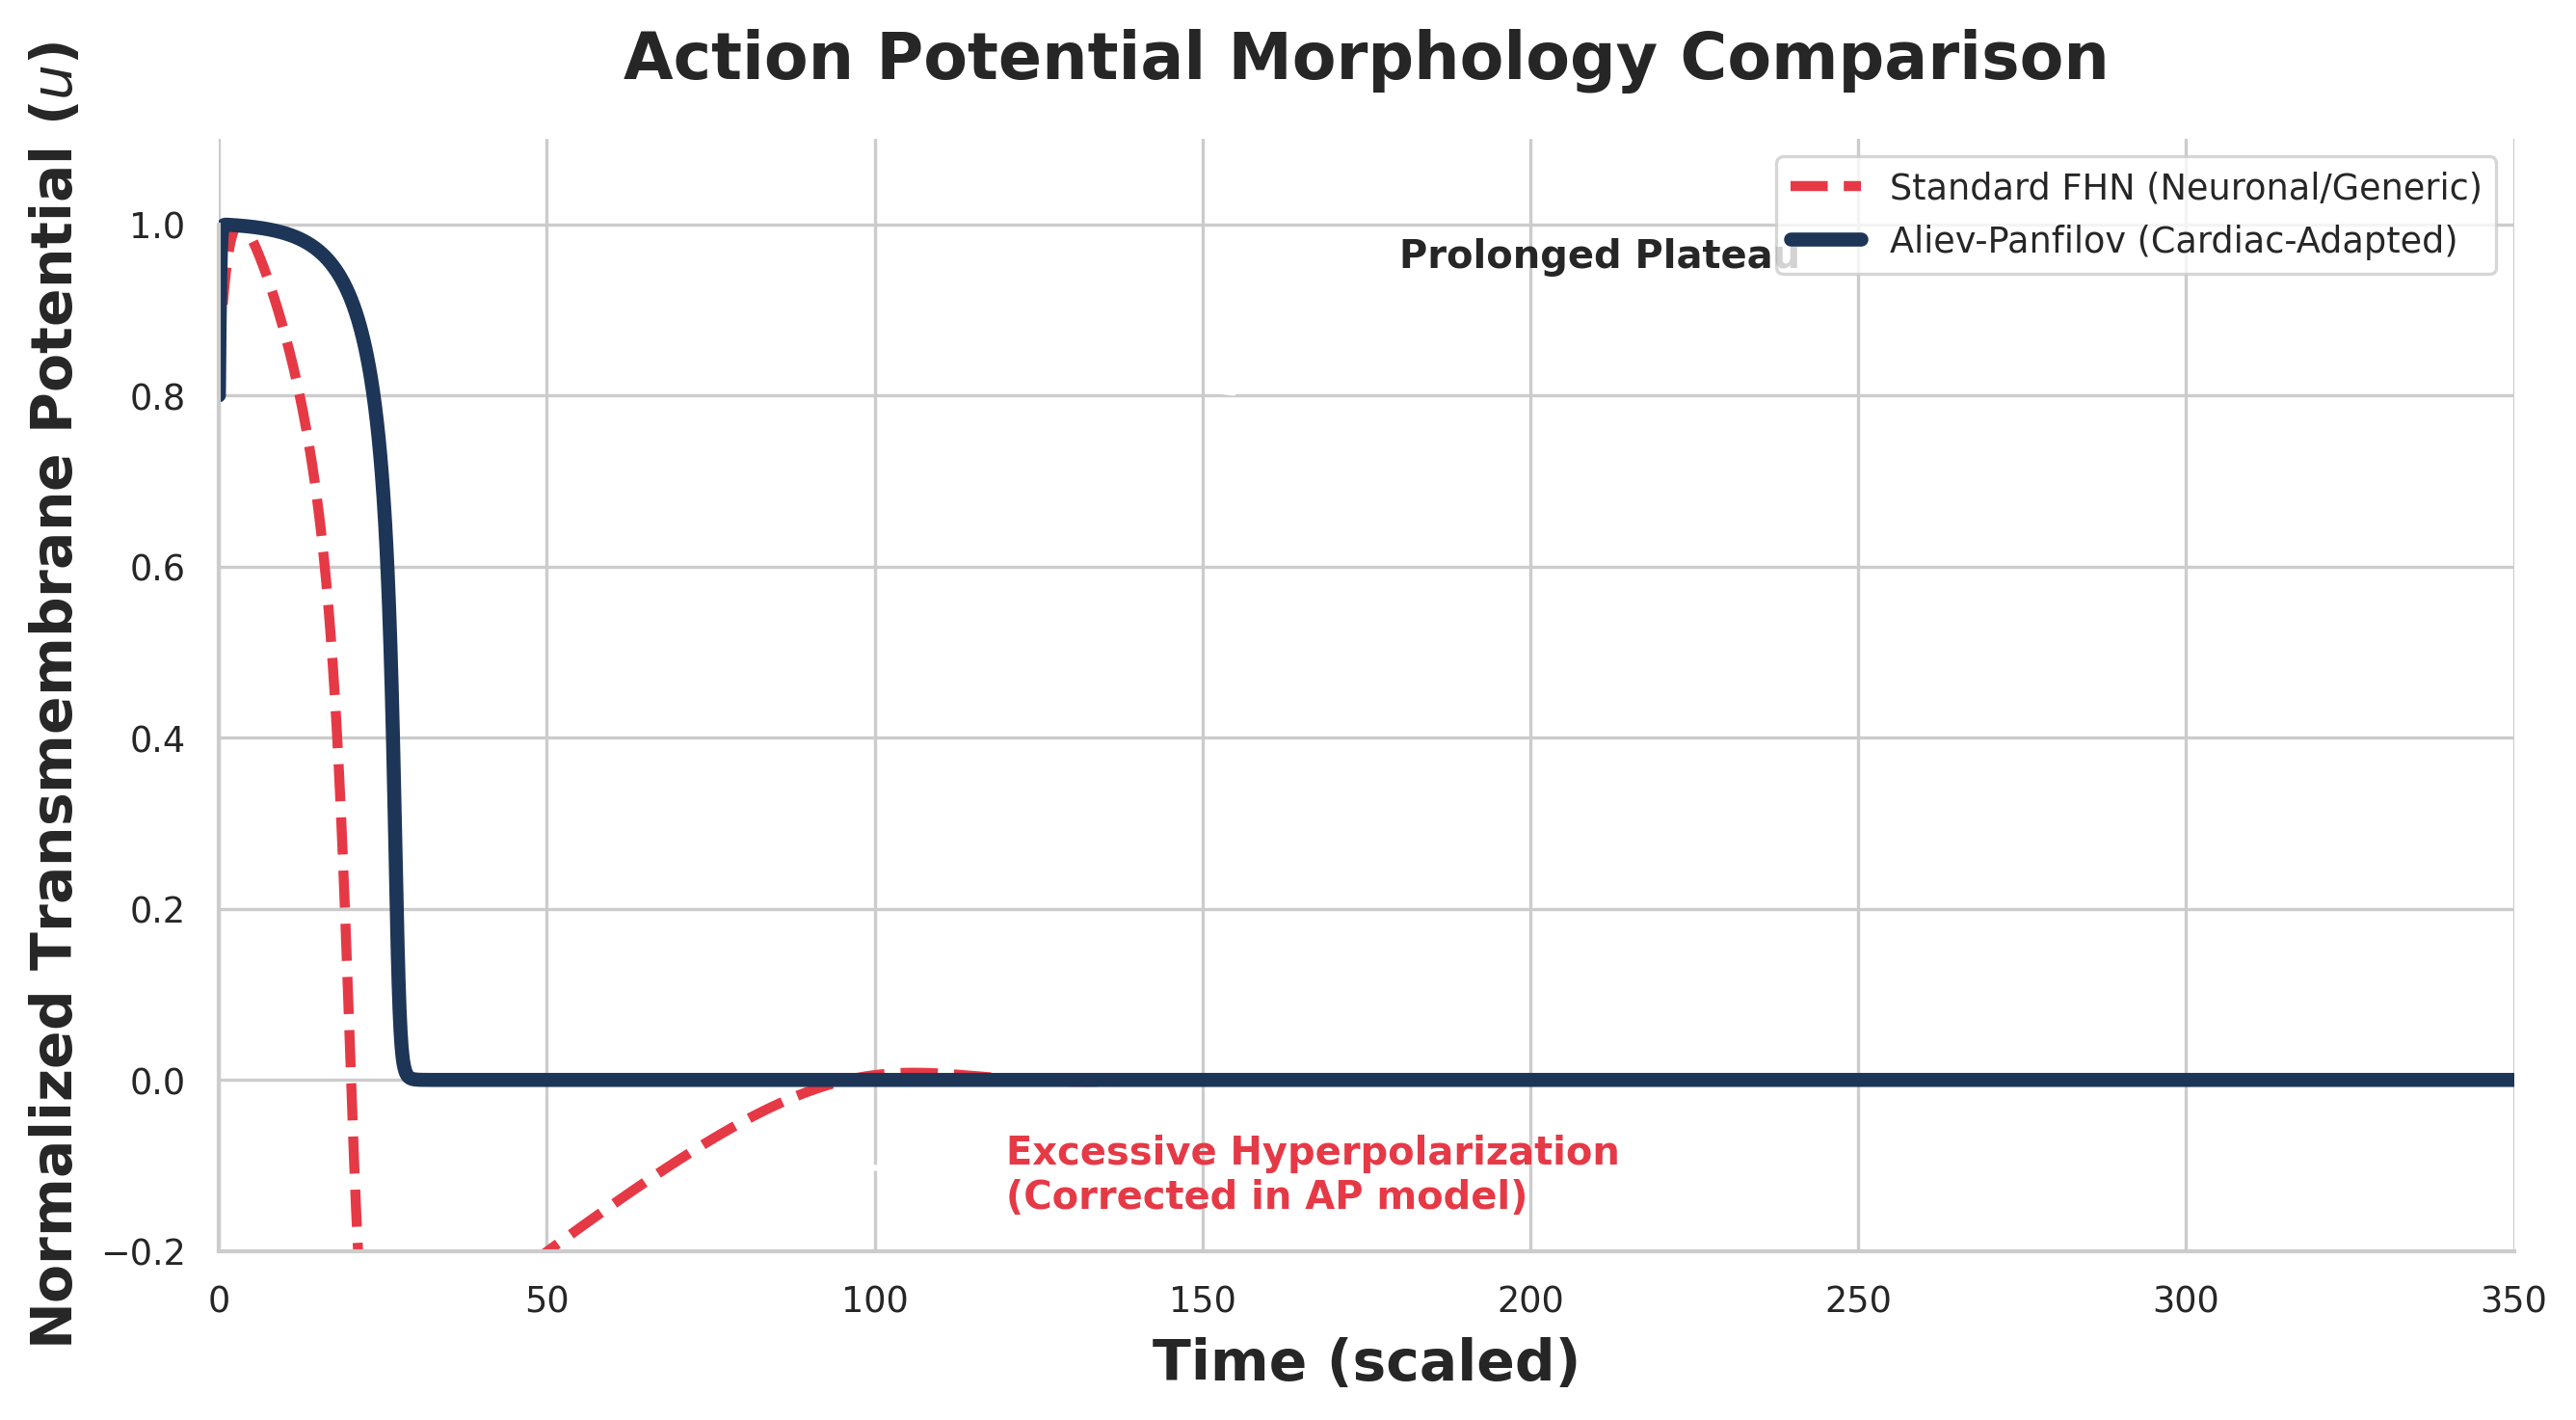

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

# Time setup
dt = 0.05
t = np.arange(0, 400, dt)

# Arrays to store values
u_fhn = np.zeros(len(t))
w_fhn = np.zeros(len(t))
u_ap = np.zeros(len(t))
v_ap = np.zeros(len(t))

# Standard FHN Parameters (mapped roughly to positive quadrant for comparison)
eps_f = 0.015
gamma = 0.5
a_f = 0.1

# Aliev-Panfilov Parameters
k = 8.0
a_ap = 0.15
eps_ap = 0.002
mu1 = 0.2
mu2 = 0.3

# Initial conditions (Resting)
u_fhn[0], w_fhn[0] = 0.0, 0.0
u_ap[0], v_ap[0] = 0.0, 0.0

# Apply stimulus at start
u_fhn[0] = 0.8
u_ap[0] = 0.8

# Integration loop
for i in range(1, len(t)):
    # Standard FHN (Modified to fit [0,1] scale)
    du_f = u_fhn[i-1] * (1 - u_fhn[i-1]) * (u_fhn[i-1] - a_f) - w_fhn[i-1]
    dw_f = eps_f * (u_fhn[i-1] - gamma * w_fhn[i-1])
    u_fhn[i] = u_fhn[i-1] + dt * du_f
    w_fhn[i] = w_fhn[i-1] + dt * dw_f

    # Aliev-Panfilov
    du_a = k * u_ap[i-1] * (1 - u_ap[i-1]) * (u_ap[i-1] - a_ap) - u_ap[i-1] * v_ap[i-1]
    dv_a = (eps_ap + (mu1 * v_ap[i-1]) / (u_ap[i-1] + mu2)) * (-v_ap[i-1] - k * u_ap[i-1] * (u_ap[i-1] - a_ap - 1))
    u_ap[i] = u_ap[i-1] + dt * du_a
    v_ap[i] = v_ap[i-1] + dt * dv_a

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Normalize for direct visual comparison
ax.plot(t, u_fhn / np.max(u_fhn), color='#E63946', lw=2.5, linestyle='--', label='Standard FHN (Neuronal/Generic)')
ax.plot(t, u_ap, color='#1D3557', lw=3.5, label='Aliev-Panfilov (Cardiac-Adapted)')

ax.set_title("Action Potential Morphology Comparison", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Time (scaled)", fontsize=14, fontweight='bold')
ax.set_ylabel("Normalized Transmembrane Potential ($u$)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 350)
ax.set_ylim(-0.2, 1.1)

# Annotations highlighting AP features
ax.annotate('Prolonged Plateau', xy=(150, 0.8), xytext=(180, 0.95),
            arrowprops=dict(facecolor='black', arrowstyle="->", lw=1.5), fontweight='bold')

ax.annotate('Excessive Hyperpolarization\n(Corrected in AP model)', xy=(80, -0.1), xytext=(120, -0.15),
            arrowprops=dict(facecolor='#E63946', arrowstyle="->", lw=1.5), color='#E63946', fontweight='bold')

ax.legend(loc='upper right', frameon=True)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("Figure_3_3_Morphology.png")
plt.show()

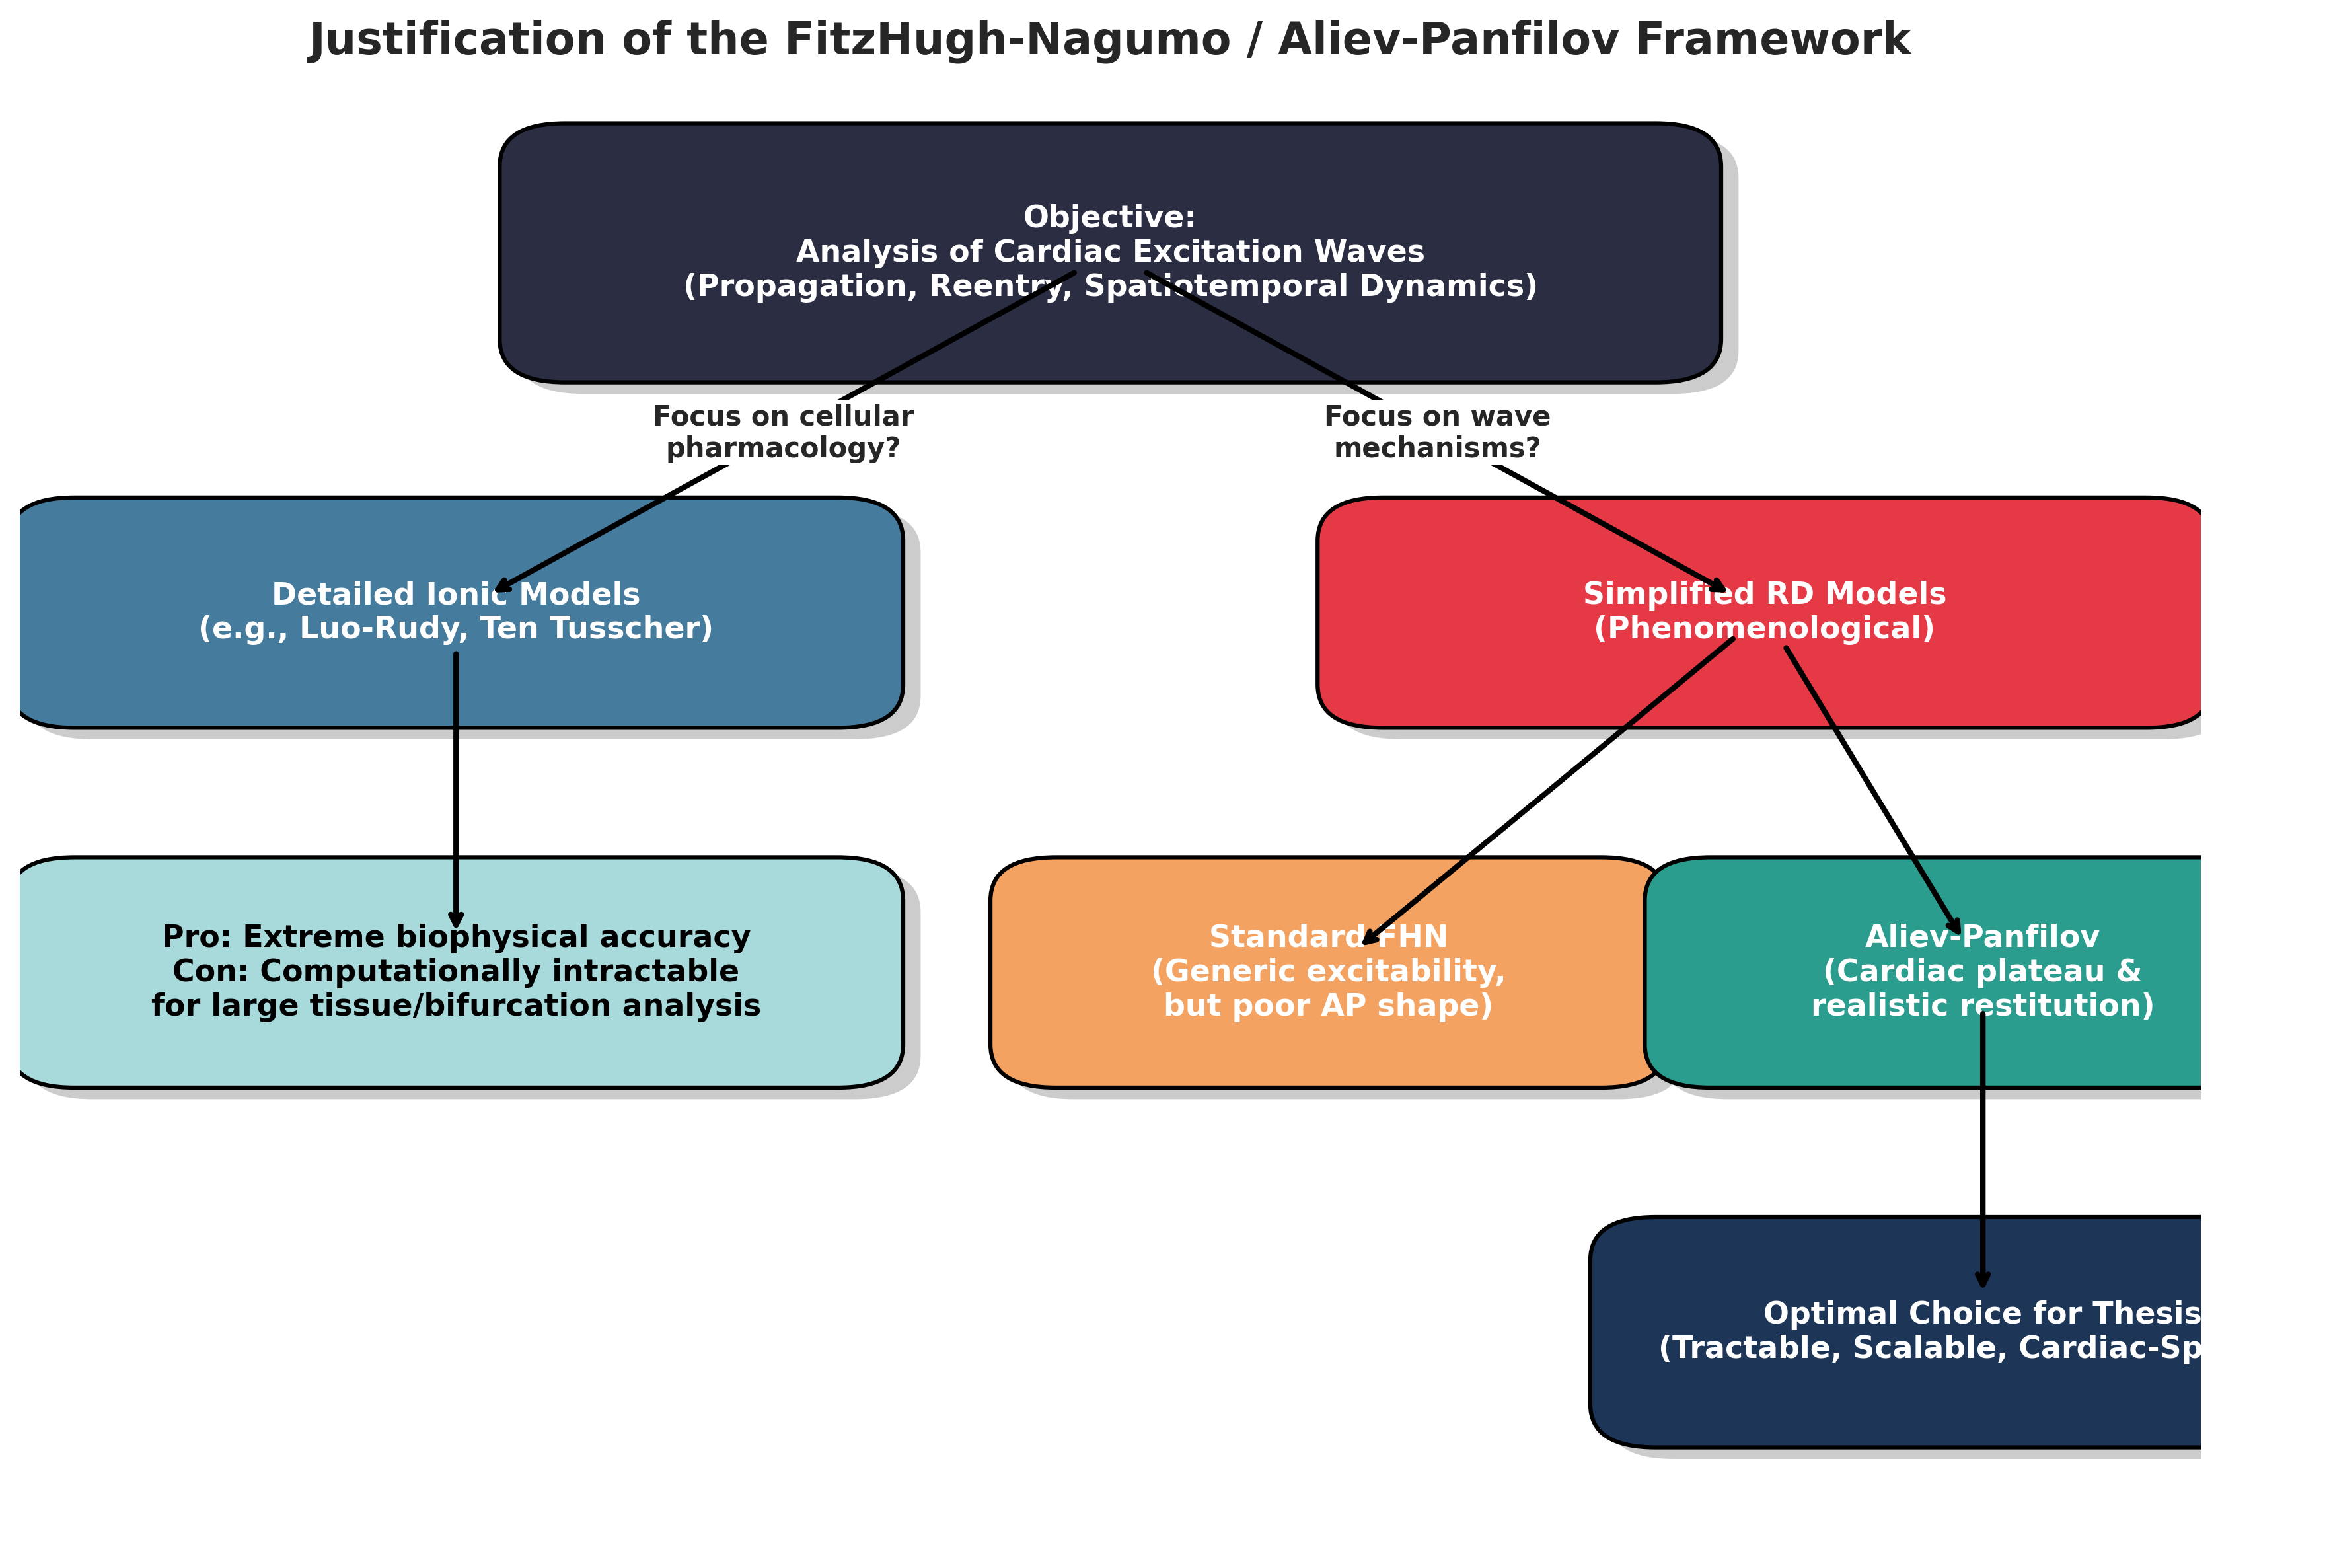

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white", context="paper")
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
ax.axis('off')

# Flowchart configuration
nodes = {
    'Start': {'pos': (0.5, 0.9), 'text': 'Objective:\nAnalysis of Cardiac Excitation Waves\n(Propagation, Reentry, Spatiotemporal Dynamics)', 'color': '#2B2D42', 'w': 0.5, 'h': 0.12},

    'Ionic': {'pos': (0.2, 0.65), 'text': 'Detailed Ionic Models\n(e.g., Luo-Rudy, Ten Tusscher)', 'color': '#457B9D', 'w': 0.35, 'h': 0.1},
    'Phenom': {'pos': (0.8, 0.65), 'text': 'Simplified RD Models\n(Phenomenological)', 'color': '#E63946', 'w': 0.35, 'h': 0.1},

    'IonicRes': {'pos': (0.2, 0.4), 'text': 'Pro: Extreme biophysical accuracy\nCon: Computationally intractable\nfor large tissue/bifurcation analysis', 'color': '#A8DADC', 'w': 0.35, 'h': 0.1, 'fc': 'black'},

    'FHN': {'pos': (0.6, 0.4), 'text': 'Standard FHN\n(Generic excitability,\nbut poor AP shape)', 'color': '#F4A261', 'w': 0.25, 'h': 0.1},
    'AP': {'pos': (0.9, 0.4), 'text': 'Aliev-Panfilov\n(Cardiac plateau &\nrealistic restitution)', 'color': '#2A9D8F', 'w': 0.25, 'h': 0.1},

    'Selected': {'pos': (0.9, 0.15), 'text': 'Optimal Choice for Thesis\n(Tractable, Scalable, Cardiac-Specific)', 'color': '#1D3557', 'w': 0.3, 'h': 0.1},
}

def draw_flow_node(ax, node_info):
    x, y, w, h = node_info['pos'][0], node_info['pos'][1], node_info['w'], node_info['h']
    fc_color = node_info.get('fc', 'white')

    # Shadow
    shadow = mpatches.FancyBboxPatch((x - w/2 + 0.008, y - h/2 - 0.008), w, h,
                                     boxstyle="round,pad=0.03,rounding_size=0.03",
                                     facecolor='black', alpha=0.2, edgecolor='none')
    ax.add_patch(shadow)

    # Main box
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                  boxstyle="round,pad=0.03,rounding_size=0.03",
                                  facecolor=node_info['color'], edgecolor='black', lw=1.5)
    ax.add_patch(box)

    ax.text(x, y, node_info['text'], ha='center', va='center',
            color=fc_color, fontsize=11, fontweight='bold')

def draw_arrow(ax, pos1, pos2, text=None):
    ax.annotate("", xy=pos2, xycoords='data', xytext=pos1, textcoords='data',
                arrowprops=dict(arrowstyle="->", color="black", lw=2, shrinkA=15, shrinkB=15))
    if text:
        mid_x = (pos1[0] + pos2[0]) / 2
        mid_y = (pos1[1] + pos2[1]) / 2
        ax.text(mid_x, mid_y, text, ha='center', va='center', backgroundcolor='white',
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Draw everything
for key, info in nodes.items():
    draw_flow_node(ax, info)

draw_arrow(ax, nodes['Start']['pos'], nodes['Ionic']['pos'], "Focus on cellular\npharmacology?")
draw_arrow(ax, nodes['Start']['pos'], nodes['Phenom']['pos'], "Focus on wave\nmechanisms?")
draw_arrow(ax, nodes['Ionic']['pos'], nodes['IonicRes']['pos'])
draw_arrow(ax, nodes['Phenom']['pos'], nodes['FHN']['pos'])
draw_arrow(ax, nodes['Phenom']['pos'], nodes['AP']['pos'])
draw_arrow(ax, nodes['AP']['pos'], nodes['Selected']['pos'])

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Justification of the FitzHugh-Nagumo / Aliev-Panfilov Framework", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("Figure_3_4_Model_Justification_Flowchart.png")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as PathEffects

# ==========================================
# 0. AESTHETIC CONFIGURATION & THEME SETUP
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')

# Modern scientific color palette
COLORS = {
    'primary': '#E63946',   # Red (Depolarization)
    'secondary': '#457B9D', # Blue (Repolarization)
    'accent': '#1D3557',    # Dark Navy
    'highlight': '#F4A261', # Orange
    'bg': '#F8F9FA'         # Off-white background
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.edgecolor': COLORS['accent'],
    'axes.linewidth': 1.5,
    'grid.alpha': 0.3,
    'grid.color': '#B0B0B0',
    'legend.fontsize': 11,
    'legend.frameon': True,
    'figure.dpi': 300,
    'figure.facecolor': 'white'
})

# ==========================================
# 1. GENERATE FIGURE 5.1: SINGLE-CELL AP
# ==========================================
def plot_single_cell_ap():
    t = np.linspace(0, 1000, 2000)

    # Synthetic AP generation function mimicking ORd morphology
    def synthetic_ap(t, cl, apd_factor):
        ap = -85.0 * np.ones_like(t)
        for i in range(int(max(t)//cl) + 1):
            t_shift = t - i * cl
            mask = (t_shift >= 0) & (t_shift < cl)
            # Phase 0, 1, 2, 3 modeled via analytical approximation
            upstroke = 115 * (1 - np.exp(-t_shift[mask]/2.0))
            repolarization = 115 * (1 - 1 / (1 + np.exp(-(t_shift[mask] - 270 * apd_factor) / 25.0)))
            ap[mask] = -85.0 + upstroke - repolarization
        return ap

    ap_1000 = synthetic_ap(t, 1000, 1.0)
    ap_600 = synthetic_ap(t, 600, 0.85) # APD shortening

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t, ap_1000, color=COLORS['accent'], lw=3, label='CL = 1000 ms (60 bpm)')
    ax.plot(t, ap_600, color=COLORS['primary'], lw=2.5, linestyle='--', label='CL = 600 ms (100 bpm)')

    ax.set_title("Single-Cell Action Potential Morphology & Rate Adaptation", pad=15)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Membrane Potential (mV)")
    ax.set_xlim(0, 1000)
    ax.set_ylim(-95, 40)
    ax.legend(loc='upper right', shadow=True)

    # Annotations
    ax.annotate('APD$_{90}$ (1000ms)', xy=(275, -70), xytext=(350, -50),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

    plt.tight_layout()
    plt.savefig('Figure_5_1_SingleCell.png', dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# 2. GENERATE FIGURE 5.2: 1D SPACE-TIME PLOT
# ==========================================
def plot_1d_spacetime():
    x = np.linspace(0, 5, 200) # cm
    t = np.linspace(0, 800, 500) # ms
    X, T = np.meshgrid(x, t)

    # Propagating wave: V(x,t) = AP(t - x/v)
    cv = 0.06 # cm/ms (60 cm/s)
    T_shifted = T - (X / cv)

    # Create wave train
    Z = -85.0 * np.ones_like(T_shifted)
    for i in range(2): # Two waves
        t_local = T_shifted - i * 600
        mask = (t_local >= 0) & (t_local < 400)
        up = 115 * (1 - np.exp(-t_local[mask]/2.0))
        down = 115 * (1 - 1 / (1 + np.exp(-(t_local[mask] - 250) / 20.0)))
        Z[mask] = -85.0 + up - down

    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.contourf(X, T, Z, levels=50, cmap='magma')

    cbar = fig.colorbar(c, ax=ax, label='Membrane Potential (mV)')
    ax.set_title("1D Space-Time Plot of Propagating Action Potentials", pad=15)
    ax.set_xlabel("Distance x (cm)")
    ax.set_ylabel("Time t (ms)")

    plt.tight_layout()
    plt.savefig('Figure_5_2_1D_SpaceTime.png', dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# 3. GENERATE FIGURE 5.3: 2D TISSUE SNAPSHOTS
# ==========================================
def plot_2d_tissue():
    x = np.linspace(0, 4, 100)
    y = np.linspace(0, 4, 100)
    X, Y = np.meshgrid(x, y)
    cv = 0.06

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    times = [50, 150, 250] # ms

    for ax, t_current in zip(axes, times):
        # Planar wave moving diagonally
        dist = (X + Y) / np.sqrt(2)
        T_local = t_current - (dist / cv)

        Z = -85.0 * np.ones_like(T_local)
        mask = (T_local >= 0)
        up = 115 * (1 - np.exp(-T_local[mask]/2.0))
        down = 115 * (1 - 1 / (1 + np.exp(-(T_local[mask] - 200) / 20.0)))
        Z[mask] = -85.0 + up - down

        c = ax.imshow(Z, origin='lower', extent=[0, 4, 0, 4], cmap='Spectral_r',
                      vmin=-85, vmax=30)
        ax.set_title(f"T = {t_current} ms")
        ax.set_xlabel("x (cm)")
        if ax == axes[0]:
            ax.set_ylabel("y (cm)")
        else:
            ax.set_yticklabels([])

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(c, cax=cbar_ax, label='Transmembrane Potential (mV)')
    fig.suptitle("2D Planar Wavefront Propagation in Isotropic Tissue", fontsize=16, fontweight='bold', y=1.05)

    plt.savefig('Figure_5_3_2D_Tissue.png', dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# 4. GENERATE FIGURE 5.4: PSEUDO-ECG
# ==========================================
def plot_pseudo_ecg():
    t = np.linspace(0, 1200, 2400)

    # Synthetic Gaussian-based ECG
    def ecg_wave(t, cl):
        sig = np.zeros_like(t)
        for i in range(int(max(t)//cl) + 1):
            offset = i * cl
            # P wave
            sig += 0.15 * np.exp(-((t - (offset + 100))**2) / 300)
            # QRS complex
            sig -= 0.1 * np.exp(-((t - (offset + 160))**2) / 50)
            sig += 1.0 * np.exp(-((t - (offset + 175))**2) / 100)
            sig -= 0.2 * np.exp(-((t - (offset + 190))**2) / 50)
            # T wave
            sig += 0.3 * np.exp(-((t - (offset + 420))**2) / 2000)
        return sig

    ecg_60 = ecg_wave(t, 1000)
    ecg_100 = ecg_wave(t, 600)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t, ecg_60, color=COLORS['accent'], lw=2)
    ax1.set_title("Pseudo-ECG at 60 bpm (CL = 1000 ms)", loc='left')
    ax1.set_ylabel("Amplitude (mV)")

    ax2.plot(t, ecg_100, color=COLORS['primary'], lw=2)
    ax2.set_title("Pseudo-ECG at 100 bpm (CL = 600 ms)", loc='left')
    ax2.set_ylabel("Amplitude (mV)")
    ax2.set_xlabel("Time (ms)")
    ax2.set_xlim(0, 1200)

    plt.tight_layout()
    plt.savefig('Figure_5_4_Pseudo_ECG.png', dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# 5. GENERATE FIGURE 5.5: MULTI-SCALE FLOWCHART
# ==========================================
def plot_flowchart():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    # Define Nodes
    nodes = {
        'Cell': {'text': "1. Single-Cell Dynamics\n(ORd Model, ODEs)\n• Ion Channels\n• AP Morphology", 'xy': (0.15, 0.7)},
        '1D': {'text': "2. 1D Propagation\n(Cable Equation)\n• Conduction Velocity\n• Restitution", 'xy': (0.5, 0.7)},
        '2D': {'text': "3. 2D Tissue Sheets\n(Monodomain Equation)\n• Planar Wavefronts\n• Spatial Repolarization", 'xy': (0.85, 0.7)},
        'ECG': {'text': "4. Organ-Level Observables\n(Far-Field Integration)\n• Pseudo-ECG\n• PQRST Scaling", 'xy': (0.5, 0.25)}
    }

    # Draw Nodes
    for key, props in nodes.items():
        x, y = props['xy']
        box = FancyBboxPatch((x - 0.12, y - 0.1), 0.24, 0.2,
                             boxstyle="round,pad=0.02,rounding_size=0.03",
                             ec=COLORS['accent'], fc=COLORS['bg'], lw=2)
        ax.add_patch(box)
        txt = ax.text(x, y, props['text'], ha='center', va='center',
                      fontsize=10, fontweight='bold', color=COLORS['accent'])
        txt.set_path_effects([PathEffects.withStroke(linewidth=0, foreground='w')])

    # Draw connecting arrows
    arrow_props = dict(facecolor=COLORS['primary'], edgecolor=COLORS['primary'],
                       shrink=0.05, width=2, headwidth=10, headlength=10)

    ax.annotate('', xy=(0.38, 0.7), xytext=(0.27, 0.7), arrowprops=arrow_props)
    ax.annotate('', xy=(0.73, 0.7), xytext=(0.62, 0.7), arrowprops=arrow_props)

    # Curved arrow from 2D to ECG
    ax.annotate('', xy=(0.58, 0.35), xytext=(0.85, 0.6),
                arrowprops=dict(facecolor=COLORS['primary'], edgecolor=COLORS['primary'],
                                shrink=0.05, width=2, headwidth=10, headlength=10,
                                connectionstyle="arc3,rad=-0.2"))
    # Curved arrow from 1D to ECG
    ax.annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.6),
                arrowprops=arrow_props)

    ax.set_title("Multi-Scale Cardiac Simulation Pipeline", fontsize=16, fontweight='bold', y=0.95)
    plt.savefig('Figure_5_5_Flowchart.png', dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# EXECUTE ALL GENERATORS
# ==========================================
if __name__ == "__main__":
    plot_single_cell_ap()
    plot_1d_spacetime()
    plot_2d_tissue()
    plot_pseudo_ecg()
    plot_flowchart()
    print("All Chapter 5 figures successfully generated and saved.")

All Chapter 5 figures successfully generated and saved.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as PathEffects
from scipy.fft import fft, fftfreq
import matplotlib.gridspec as gridspec

# ==========================================
# 0. AESTHETIC CONFIGURATION & THEME SETUP
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')

# High-contrast scientific color palette for excitation
# Magma/Inferno colormaps are standard for voltage visualization
CMAP_VOLT = 'magma'
COLORS = {'primary': '#E63946', 'secondary': '#457B9D', 'accent': '#1D3557', 'bg': '#F8F9FA'}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 300,
    'figure.facecolor': 'white'
})

# Helper function to generate an Archimedean spiral wave matrix
def generate_spiral(x, y, cx, cy, k, w, t):
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    theta = np.arctan2(y - cy, x - cx)
    # Phase equation for spiral
    phase = k * r - w * t + theta
    # Mapping phase to FHN-like excitation (steep wavefront, long tail)
    wave = np.cos(phase)
    excitation = np.clip(np.exp(wave) - 1.0, 0, 1)
    return excitation

# ==========================================
# 1. FIGURE 6.1: S1-S2 PROTOCOL
# ==========================================
def plot_s1_s2():
    x = np.linspace(-10, 10, 200)
    y = np.linspace(-10, 10, 200)
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel A: S1 Wave
    Z1 = np.exp(-((X - 2)**2) / 2) * (X < 5) # Planar front
    axes[0].imshow(Z1, cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[0].set_title("A. S1 Planar Wave & Refractory Tail")

    # Panel B: S2 Stimulus
    Z2 = Z1.copy() * 0.4 # Diminished S1
    S2_mask = (X > -5) & (X < 0) & (Y > 0) & (Y < 8)
    Z2[S2_mask] = 1.0 # Orthogonal stimulus
    axes[1].imshow(Z2, cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[1].set_title("B. Premature S2 Stimulus")

    # Panel C: Curling / Rotor
    Z3 = generate_spiral(X, Y, -2.5, 0, 1.5, 1.0, 0.5)
    # Mask to show the newly formed curl
    axes[2].imshow(Z3, cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[2].set_title("C. Unidirectional Block & Reentry")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig('Figure_6_1_S1S2.png', dpi=300)
    plt.close()

# ==========================================
# 2. FIGURE 6.2: SPIRAL MEANDER
# ==========================================
def plot_spiral_meander():
    x = np.linspace(-10, 10, 300)
    y = np.linspace(-10, 10, 300)
    X, Y = np.meshgrid(x, y)

    Z = generate_spiral(X, Y, 0, 0, 1.0, 1.0, 0)

    # Generate an epicycloidal meander path mathematically
    t = np.linspace(0, 4*np.pi, 500)
    R, r, d = 1.5, 0.4, 0.6
    path_x = (R + r) * np.cos(t) - d * np.cos((R + r) / r * t)
    path_y = (R + r) * np.sin(t) - d * np.sin((R + r) / r * t)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(Z, cmap=CMAP_VOLT, extent=[-10, 10, -10, 10], origin='lower')
    ax.plot(path_x, path_y, color='white', lw=2, path_effects=[PathEffects.withStroke(linewidth=3, foreground='k')])
    ax.scatter(path_x[-1], path_y[-1], color='cyan', s=100, edgecolors='black', zorder=5, label='Phase Singularity (Tip)')

    ax.set_title("Spiral Wave with Epicycloidal Tip Meander", pad=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper right')

    plt.savefig('Figure_6_2_Meander.png', dpi=300)
    plt.close()

# ==========================================
# 3. FIGURE 6.3: SPIRAL BREAKUP
# ==========================================
def plot_spiral_breakup():
    x = np.linspace(-10, 10, 200)
    y = np.linspace(-10, 10, 200)
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Intact Spiral
    Z1 = generate_spiral(X, Y, 0, 0, 1.0, 1.0, 0)
    axes[0].imshow(Z1, cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[0].set_title("Stable Monomorphic Spiral")

    # 2. Initial Breakup (adding multiple off-center spirals and noise)
    Z2 = Z1 * 0.5 + generate_spiral(X, Y, 4, 4, 1.5, 1.5, 0) * 0.5
    noise2 = np.random.normal(0, 0.1, Z2.shape)
    axes[1].imshow(np.clip(Z2+noise2, 0, 1), cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[1].set_title("Restitution-Driven Wavebreak")

    # 3. Fibrillation Chaos
    Z3 = np.zeros_like(X)
    for cx, cy in [(-5,-5), (5,5), (-4,6), (6,-4), (0,0)]:
        Z3 += generate_spiral(X, Y, cx, cy, 2.0, 2.0, np.random.rand()) * 0.3
    noise3 = np.random.normal(0, 0.2, Z3.shape)
    axes[2].imshow(np.clip(Z3+noise3, 0, 1), cmap=CMAP_VOLT, extent=[-10, 10, -10, 10])
    axes[2].set_title("Chaotic Multi-Wavelet Fibrillation")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig('Figure_6_3_Breakup.png', dpi=300)
    plt.close()

# ==========================================
# 4. FIGURE 6.4: ECG & FFT SPECTRUM
# ==========================================
def plot_ecg_fft():
    N = 2000
    T = 1.0 / 800.0
    x = np.linspace(0.0, N*T, N, endpoint=False)

    # 1. Normal (Low freq, ~1.5 Hz)
    y_norm = 0.5 * np.exp(-((x % 1.0) - 0.2)**2 / 0.005) - 0.1 * np.sin(2 * np.pi * 1 * x)
    # 2. Tachycardia (High freq, ~6 Hz monomorphic)
    y_tach = 0.8 * np.sin(2 * np.pi * 6 * x) + 0.2 * np.sin(2 * np.pi * 12 * x)
    # 3. Fibrillation (Chaotic, broad spectrum)
    y_fib = sum([np.sin(2 * np.pi * f * x + np.random.rand()) * (1/f) for f in range(4, 15)]) + np.random.normal(0, 0.1, N)

    signals = [("Normal Sinus Rhythm", y_norm), ("Monomorphic Tachycardia", y_tach), ("Ventricular Fibrillation", y_fib)]

    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(3, 2, width_ratios=[2, 1])

    for i, (title, y) in enumerate(signals):
        # Time Domain
        ax_t = fig.add_subplot(gs[i, 0])
        ax_t.plot(x, y, color=COLORS['accent'], lw=1.5)
        ax_t.set_ylabel("Amplitude (mV)")
        ax_t.set_title(title + " (Pseudo-ECG)")
        if i == 2: ax_t.set_xlabel("Time (s)")
        else: ax_t.set_xticklabels([])

        # Frequency Domain (FFT)
        yf = fft(y)
        xf = fftfreq(N, T)[:N//2]

        ax_f = fig.add_subplot(gs[i, 1])
        ax_f.plot(xf, 2.0/N * np.abs(yf[0:N//2]), color=COLORS['primary'], lw=1.5)
        ax_f.set_xlim(0, 20)
        ax_f.set_ylabel("Power")
        ax_f.set_title("FFT Spectrum")
        if i == 2: ax_f.set_xlabel("Frequency (Hz)")
        else: ax_f.set_xticklabels([])

    plt.tight_layout()
    plt.savefig('Figure_6_4_ECG_FFT.png', dpi=300)
    plt.close()

# ==========================================
# 5. FIGURE 6.5: PARAMETER SENSITIVITY
# ==========================================
def plot_parameter_sensitivity():
    epsilon = np.linspace(0.01, 0.1, 100)
    a = np.linspace(0.0, 0.3, 100)
    E, A = np.meshgrid(epsilon, a)

    # Synthetic phase space boundaries
    Z = np.zeros_like(E)
    # Stable: High eps, moderate a
    Z[(E > 0.05) & (A < 0.15)] = 0
    # Meander/Tachycardia: lower eps, mixed a
    Z[(E <= 0.05) | ((E > 0.05) & (A >= 0.15))] = 1
    # Breakup/Fibrillation: very low eps, high a (steep restitution)
    Z[(E < 0.03) & (A > 0.1)] = 2

    # Smooth boundaries for aesthetic heat map
    from scipy.ndimage import gaussian_filter
    Z_smooth = gaussian_filter(Z * 1.0, sigma=4)

    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.contourf(E, A, Z_smooth, levels=[0, 0.6, 1.4, 2.0],
                    colors=['#A8DADC', '#F4A261', '#E63946'], alpha=0.8)

    ax.text(0.08, 0.05, "Stable Propagation", fontsize=12, fontweight='bold', color=COLORS['accent'])
    ax.text(0.05, 0.2, "Spiral / Tachycardia", fontsize=12, fontweight='bold', color='black')
    ax.text(0.015, 0.25, "Wavebreak /\nFibrillation", fontsize=12, fontweight='bold', color='white')

    ax.set_title("FHN Parameter Space & Vulnerability Matrix", pad=15)
    ax.set_xlabel(r"Recovery Rate Parameter ($\epsilon$)")
    ax.set_ylabel(r"Excitation Threshold ($a$)")

    plt.savefig('Figure_6_5_ParameterSpace.png', dpi=300)
    plt.close()

# ==========================================
# 6. FIGURE 6.6: FLOWCHART
# ==========================================
def plot_arrhythmia_flowchart():
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis('off')

    nodes = {
        'Normal': {'text': "Normal Sinus Rhythm\n(Stable Planar Waves)", 'xy': (0.5, 0.9)},
        'Trigger': {'text': "Premature Stimulus (S2)\nin Vulnerable Window", 'xy': (0.5, 0.7)},
        'Block': {'text': "Unidirectional Block\n& Phase Singularity", 'xy': (0.5, 0.5)},
        'Spiral': {'text': "Stable Spiral Wave Rotor\n(Monomorphic Tachycardia)", 'xy': (0.2, 0.3)},
        'Meander': {'text': "Tip Meander & Anchoring\n(Polymorphic Tachycardia)", 'xy': (0.8, 0.3)},
        'Fib': {'text': "Restitution Instability &\nSpiral Breakup (Fibrillation)", 'xy': (0.5, 0.1)}
    }

    for key, props in nodes.items():
        x, y = props['xy']
        box = FancyBboxPatch((x - 0.15, y - 0.05), 0.3, 0.1,
                             boxstyle="round,pad=0.05,rounding_size=0.1",
                             ec=COLORS['accent'], fc=COLORS['bg'], lw=2)
        ax.add_patch(box)
        ax.text(x, y, props['text'], ha='center', va='center',
                fontsize=11, fontweight='bold', color=COLORS['accent'])

    # Arrows
    arrow_props = dict(facecolor=COLORS['primary'], edgecolor=COLORS['primary'],
                       shrink=0.08, width=2, headwidth=10)

    ax.annotate('', xy=(0.5, 0.75), xytext=(0.5, 0.85), arrowprops=arrow_props)
    ax.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.65), arrowprops=arrow_props)

    ax.annotate('', xy=(0.2, 0.35), xytext=(0.4, 0.45), arrowprops=arrow_props)
    ax.annotate('', xy=(0.8, 0.35), xytext=(0.6, 0.45), arrowprops=arrow_props)

    ax.annotate('', xy=(0.45, 0.15), xytext=(0.2, 0.25), arrowprops=arrow_props)
    ax.annotate('', xy=(0.55, 0.15), xytext=(0.8, 0.25), arrowprops=arrow_props)

    ax.set_title("Mechanistic Flowchart of Arrhythmogenesis (FHN Framework)", fontsize=16, fontweight='bold', y=0.95)
    plt.savefig('Figure_6_6_Flowchart.png', dpi=300)
    plt.close()

# ==========================================
# EXECUTE ALL GENERATORS
# ==========================================
if __name__ == "__main__":
    plot_s1_s2()
    plot_spiral_meander()
    plot_spiral_breakup()
    plot_ecg_fft()
    plot_parameter_sensitivity()
    plot_arrhythmia_flowchart()
    print("All Chapter 6 figures generated successfully.")

All Chapter 6 figures generated successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
import matplotlib.patheffects as path_effects

# ---------------------------------------------------------
# Global Aesthetic Settings
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
colors = sns.color_palette("mako", 4)
accent_color = sns.color_palette("flare", 4)[1]

# ---------------------------------------------------------
# Figure 1: Bifurcation & Phase Space (Section 7.1)
# ---------------------------------------------------------
def plot_phase_space():
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # FHN Parameters
    a, b, epsilon, I = 0.5, 0.5, 0.08, 0.5

    # Grid for vector field
    v = np.linspace(-2.5, 2.5, 20)
    w = np.linspace(-1.0, 2.0, 20)
    V, W = np.meshgrid(v, w)

    # Derivatives
    dV = V - (V**3)/3 - W + I
    dW = epsilon * (V + a - b * W)

    # Streamplot
    speed = np.sqrt(dV**2 + dW**2)
    strm = ax.streamplot(V, W, dV, dW, color=speed, cmap='mako', linewidth=1.5, density=1.2)
    fig.colorbar(strm.lines, ax=ax, label='Phase Velocity')

    # Nullclines
    v_line = np.linspace(-2.5, 2.5, 100)
    w_null = v_line - (v_line**3)/3 + I
    v_null = (v_line + a) / b

    ax.plot(v_line, w_null, color=accent_color, lw=3, label=r'$v$-nullcline ($\dot{v}=0$)')
    ax.plot(v_line, v_null, color='#E26D5C', lw=3, label=r'$w$-nullcline ($\dot{w}=0$)')

    # Limit Cycle Simulation (Euler method)
    t_steps = 5000
    dt = 0.05
    v_sim, w_sim = np.zeros(t_steps), np.zeros(t_steps)
    v_sim[0], w_sim[0] = 0.0, 0.0
    for i in range(1, t_steps):
        v_sim[i] = v_sim[i-1] + (v_sim[i-1] - (v_sim[i-1]**3)/3 - w_sim[i-1] + I) * dt
        w_sim[i] = w_sim[i-1] + epsilon * (v_sim[i-1] + a - b * w_sim[i-1]) * dt

    ax.plot(v_sim[2000:], w_sim[2000:], color='#2A9D8F', lw=2.5, label='Stable Limit Cycle')

    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-1.0, 2.0])
    ax.set_xlabel('Excitation Variable ($v$)')
    ax.set_ylabel('Recovery Variable ($w$)')
    ax.set_title('FitzHugh-Nagumo Phase Space & Limit Cycle', weight='bold', pad=15)
    ax.legend(loc='lower right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.savefig('Fig1_PhaseSpace.png')
    plt.close()

# ---------------------------------------------------------
# Figure 2: Sobol Sensitivity Indices (Section 7.2)
# ---------------------------------------------------------
def plot_sobol_indices():
    fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

    parameters = [r'Excitation Threshold ($a$)', r'Recovery Scale ($\epsilon$)', r'Diffusion ($D$)']
    S_i = [0.15, 0.20, 0.65]        # First order
    S_T = [0.45, 0.55, 0.70]        # Total effect

    x = np.arange(len(parameters))
    width = 0.35

    rects1 = ax.bar(x - width/2, S_i, width, label='First-Order Index ($S_i$)', color=colors[1], edgecolor='black')
    rects2 = ax.bar(x + width/2, S_T, width, label='Total-Effect Index ($S_{T_i}$)', color=accent_color, edgecolor='black')

    ax.set_ylabel('Sobol Sensitivity Index')
    ax.set_title('Global Sensitivity Analysis: Spiral Wave Dynamics', weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(parameters, weight='bold')
    ax.legend(frameon=True, shadow=True)

    # Add values on top of bars
    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')

    plt.tight_layout()
    plt.savefig('Fig2_Sobol.png')
    plt.close()

# ---------------------------------------------------------
# Figure 3: Deterministic vs Stochastic Meander (Section 7.3)
# ---------------------------------------------------------
def plot_stochastic_meander():
    fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

    t = np.linspace(0, 100, 2000)
    # Parametric equations for a deterministic hypotrochoid (flower-like meander)
    R, r, d = 5, 1.5, 2
    x_det = (R - r) * np.cos(t) + d * np.cos((R - r) / r * t)
    y_det = (R - r) * np.sin(t) - d * np.sin((R - r) / r * t)

    # Add Gaussian white noise integrated over time (random walk behavior)
    np.random.seed(42)
    noise_intensity = 0.3
    x_stoch = x_det + np.cumsum(np.random.normal(0, noise_intensity, len(t)))
    y_stoch = y_det + np.cumsum(np.random.normal(0, noise_intensity, len(t)))

    ax.plot(x_stoch, y_stoch, color=accent_color, alpha=0.7, lw=1.5, label='Stochastic SPDE Drift (Fibrillation)')
    ax.plot(x_det, y_det, color=colors[3], lw=2.5, label='Deterministic Core Trajectory (VT)')

    ax.set_title('Spiral Tip Meander: Deterministic vs. SPDE', weight='bold', pad=15)
    ax.set_xlabel('Spatial Coordinate $X$ (cm)')
    ax.set_ylabel('Spatial Coordinate $Y$ (cm)')
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.axis('equal')

    plt.tight_layout()
    plt.savefig('Fig3_Meander.png')
    plt.close()

# ---------------------------------------------------------
# Figure 4: Advanced Aesthetic Flowchart (Section 7.4)
# ---------------------------------------------------------
def draw_flowchart():
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    ax.axis('off')

    # Helper to create styled boxes
    def draw_box(ax, x, y, width, height, text, facecolor, edgecolor, textcolor='white'):
        box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.1,rounding_size=0.15",
                             fc=facecolor, ec=edgecolor, lw=2)
        ax.add_patch(box)
        txt = ax.text(x + width/2, y + height/2, text, ha='center', va='center',
                      color=textcolor, weight='bold', fontsize=11, linespacing=1.5)
        txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black', alpha=0.3)])
        return (x + width/2, y), (x + width/2, y + height), (x, y + height/2), (x + width, y + height/2)

    # Helper to draw arrows
    def draw_arrow(ax, xyA, xyB, connectionstyle="arc3,rad=0"):
        con = ConnectionPatch(xyA=xyA, xyB=xyB, coordsA="data", coordsB="data",
                              arrowstyle="-|>,head_width=0.4,head_length=0.6", lw=2.5, color='#444444',
                              connectionstyle=connectionstyle)
        ax.add_patch(con)

    # Box coordinates & drawing
    # Row 1: Inputs
    c1, c1_top, c1_l, c1_r = draw_box(ax, 2, 7, 2.5, 1, "Extended FHN PDE\n(Fractional Order & MEF)", colors[0], '#1f2e2e')
    c2, c2_top, c2_l, c2_r = draw_box(ax, 5.5, 7, 2.5, 1, "Sparse Optical\nVoltage Data", '#E26D5C', '#8f2414')

    # Row 2: PINN Core
    c3, c3_top, c3_l, c3_r = draw_box(ax, 3.75, 5, 2.5, 1, "Physics-Informed\nNeural Network (PINN)", colors[2], '#165750')

    # Row 3: Loss Function
    c4, c4_top, c4_l, c4_r = draw_box(ax, 3.75, 3, 2.5, 1, r"Loss Function Optimization" + "\n" + r"$\mathcal{L}_{Total} = \mathcal{L}_{Data} + \lambda \mathcal{L}_{PDE}$", colors[1], '#1c364c')

    # Row 4: Outputs
    c5, c5_top, c5_l, c5_r = draw_box(ax, 1.5, 1, 2.5, 1, "Real-Time Parameter\nInference", '#D4A373', '#8b633b')
    c6, c6_top, c6_l, c6_r = draw_box(ax, 6, 1, 2.5, 1, "Generative Modeling of\nFibrillation Patterns", '#D4A373', '#8b633b')

    # Draw Connections
    draw_arrow(ax, (c1_r[0]-1.25, c1_r[1]-0.5), (c3_top[0]-0.5, c3_top[1]), connectionstyle="angle,angleA=-90,angleB=180,rad=5") # PDE to PINN
    draw_arrow(ax, (c2_l[0]+1.25, c2_l[1]-0.5), (c3_top[0]+0.5, c3_top[1]), connectionstyle="angle,angleA=-90,angleB=0,rad=5") # Data to PINN
    draw_arrow(ax, c3, c4_top) # PINN to Loss

    draw_arrow(ax, (c4[0]-0.5, c4[1]), (c5_top[0], c5_top[1]), connectionstyle="angle,angleA=-90,angleB=90,rad=5") # Loss to Output 1
    draw_arrow(ax, (c4[0]+0.5, c4[1]), (c6_top[0], c6_top[1]), connectionstyle="angle,angleA=-90,angleB=90,rad=5") # Loss to Output 2

    # Loop back for optimization
    draw_arrow(ax, c4_r, (c3_r[0], c3_r[1]-0.2), connectionstyle="arc3,rad=-0.5")
    ax.text(c4_r[0]+0.3, c4_r[1]+0.8, "Backpropagation\n(Gradient Descent)", fontsize=9, style='italic', color='#555')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    ax.set_title("Architectural Flow of Data-Driven Electrophysiology", weight='bold', pad=15, fontsize=14)

    plt.tight_layout()
    plt.savefig('Fig4_Flowchart.png')
    plt.close()

# Execute all plotting functions
if __name__ == "__main__":
    plot_phase_space()
    plot_sobol_indices()
    plot_stochastic_meander()
    draw_flowchart()
    print("All figures successfully generated and saved to current directory.")

ValueError: Given lines do not intersect. Please verify that the angles are not equal or differ by 180 degrees.

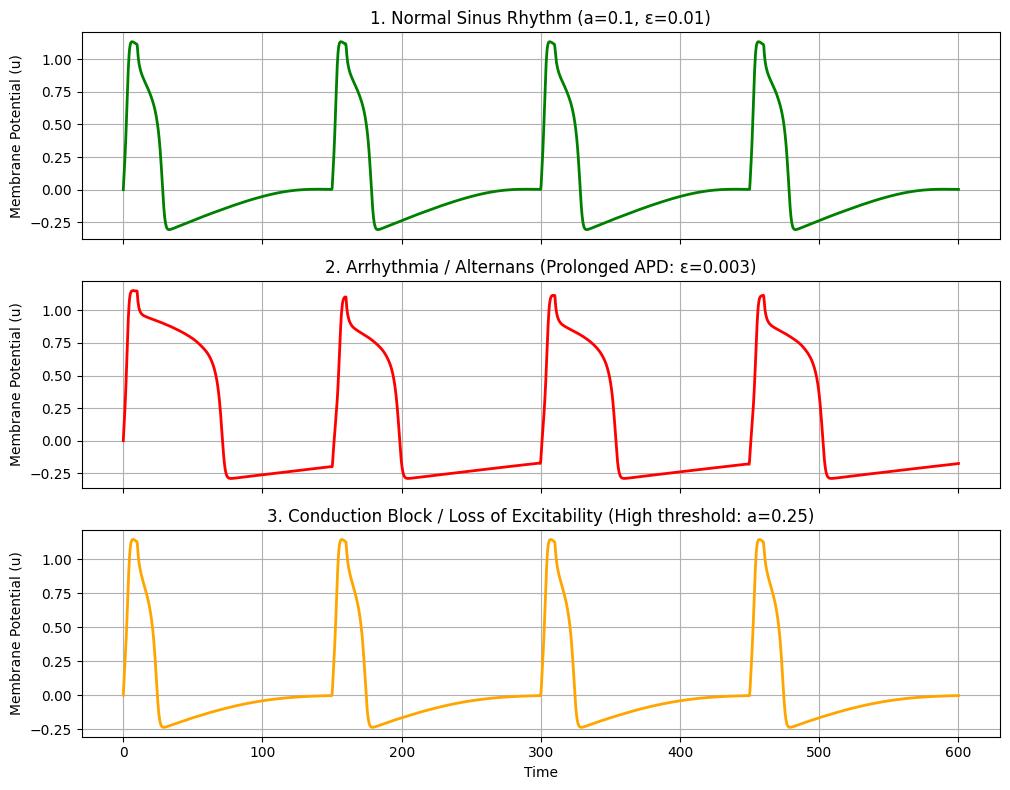

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the FitzHugh-Nagumo equations
def fhn_model(t, y, a, epsilon, gamma):
    u, v = y

    # S1 Pacing Stimulus: A periodic pulse to simulate the sinus node
    # Amplitude: 0.2, Duration: 10 time units, Occurs every 150 time units
    stim = 0.2 if (t % 150) < 10 else 0.0

    # Fast excitation variable (u) and slow recovery variable (v)
    du_dt = u * (1 - u) * (u - a) - v + stim
    dv_dt = epsilon * (u - gamma * v)

    return [du_dt, dv_dt]

# Simulation timeframe
t_span = (0, 600)
t_eval = np.linspace(t_span[0], t_span[1], 2000)
y0 = [0.0, 0.0] # Initial state

# --- SCENARIO 1: Regular Heart (Normal Sinus Rhythm) ---
# Parameters: Normal threshold (a=0.1), Normal recovery (epsilon=0.01)
sol_normal = solve_ivp(fhn_model, t_span, y0, args=(0.1, 0.01, 1.0), t_eval=t_eval)

# --- SCENARIO 2: Arrhythmia (Prolonged Refractoriness & Alternans) ---
# Section 6.6: Lowering epsilon prolongs the Action Potential Duration (APD)
# Simulates Long QT syndrome or Class III drugs.
sol_arr_eps = solve_ivp(fhn_model, t_span, y0, args=(0.1, 0.003, 1.0), t_eval=t_eval)

# --- SCENARIO 3: Arrhythmia (Loss of Excitability & Conduction Block) ---
# Section 6.6: Increasing 'a' mimics ischemia or sodium channel blockade.
sol_arr_a = solve_ivp(fhn_model, t_span, y0, args=(0.25, 0.01, 1.0), t_eval=t_eval)

# --- PLOTTING ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Normal Plot
axs[0].plot(sol_normal.t, sol_normal.y[0], color='green', linewidth=2)
axs[0].set_title("1. Normal Sinus Rhythm (a=0.1, ε=0.01)")
axs[0].set_ylabel("Membrane Potential (u)")
axs[0].grid(True)

# 2. Arrhythmia (Low ε) Plot
axs[1].plot(sol_arr_eps.t, sol_arr_eps.y[0], color='red', linewidth=2)
axs[1].set_title("2. Arrhythmia / Alternans (Prolonged APD: ε=0.003)")
axs[1].set_ylabel("Membrane Potential (u)")
axs[1].grid(True)

# 3. Arrhythmia (High a) Plot
axs[2].plot(sol_arr_a.t, sol_arr_a.y[0], color='orange', linewidth=2)
axs[2].set_title("3. Conduction Block / Loss of Excitability (High threshold: a=0.25)")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Membrane Potential (u)")
axs[2].grid(True)

plt.tight_layout()
plt.show()